In [1]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import statsmodels.api as sm
from scipy.odr import ODR, Model, RealData
from matplotlib.colors import LogNorm
from sklearn.cluster import KMeans


In [2]:
def CCN_CDNC_Dataset(CCN_ds, CDNC_da):
    """
    Compute OLS slope/intercept between CCN(radius, lev, time)
    and CDNC(lev, time) across 'time'.
    """
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)

   
    
    ds_out = xr.Dataset(
        data_vars={
            'CCN': CCN_aligned,       # dims: (radius, lev, time)
            'CDNC': CDNC_aligned      # dims: (lev, time)
        },
        coords={
            'radius': CCN_aligned.radius,
            'lev': CCN_aligned.lev,
            'time': CCN_aligned.time
        }
    )

    return ds_out


In [3]:
NorPath = "/share/sabl0586/all_stations_NorESM_OsloAero_prcp2szdst_f19_f19_noresmv211_corr_ilevall_levs_4Peter.nc"
ds = xr.open_dataset(NorPath, chunks={})
stations = ds["station"].values
radii = np.logspace(0, 2.7, 61) #1 to 500 nm RADIUS
VarList = ['FREQL', 'Z3']
x = xr.DataArray(np.logspace(-0.5,6, num=200), dims =['D'], coords= {'D':np.logspace(-0.5,6, num=200)})

In [4]:
height = ds['Z3'].mean('time')

In [5]:
all_stationsCCN = []
all_stationsHeight = []
#CCN_all = xr.open_dataset('/share/pech2273/NorESM_CCN_CDNC.nc')
Downloaded = False
for station in stations:
    if Downloaded is False:
        
        Nor_ds = Function.NorESMExtract_Dask(NorPath, station, VarList, x, PNSD=False)
        CCN_ds = Function.NorERF(Nor_ds, radii)
        
        ## Mask when cloud coverage is above 80%
        Levels_CCN_ds = CCN_CDNC_Dataset(CCN_ds, Nor_ds['CDNC'].where(Nor_ds['FREQL']>0.8))
        all_stationsCCN.append(Levels_CCN_ds.assign_coords(station=station))


# Concatenate across stations
if Downloaded is False:
    CCN_all = xr.concat(all_stationsCCN, dim='station')



#Susceptibility_all = Susceptibility_all.compute()
CCN_all = CCN_all.compute()

/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


In [6]:
CCN_all.CDNC.sel(station = 'FKL').dropna('time', how = 'all')

<xarray.DataArray 'CDNC' (time: 460, lev: 32)> Size: 59kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(460, 32), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 4kB 2012-01-03T18:00:00 ... 2014-12-29T09:...
    station  <U8 32B 'FKL'
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6

In [4]:
bins = np.logspace(0, 4, 101)  # 10^0=1, 10^4=10000'

In [8]:
testbins = np.linspace(np.log10(10**0), np.log10(10**4),101)

In [10]:
bins - 10**testbins

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [7]:
#CCN_all.to_netcdf('/share/pech2273/NorESM_CCN_CDNC.nc')

In [8]:
stations = CCN_all.station.values

# Pre-allocate Dataset
reg_ds = xr.Dataset(
    data_vars={
        "slope":   (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),
        "r_value": (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),
        "std_err": (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),
        "intercept": (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),

    },
    coords={
        "station": stations,
        "radius": radii
    }
)
#reg_ds = xr.open_dataset('/share/pech2273/NorESM_Susceptibility_All_level.nc')
Downloaded = False
# Loop over stations and radii
if Downloaded is False:
    for s, station in enumerate(stations):
        for r in range(len(radii)):
    
            CCN_slice = CCN_all['CCN'].sel(station=station).isel(radius=r)
            CDNC_slice = CCN_all['CDNC'].sel(station=station)
    
            # Bin by CCN
            CCN_binned = CCN_slice.groupby_bins(CCN_slice, bins).mean()
            CDNC_binned = CDNC_slice.groupby_bins(CCN_slice, bins).mean()
    
            x = np.log10(CCN_binned.values)
            y = np.log10(CDNC_binned.values)
    
            mask = np.isfinite(x) & np.isfinite(y)
    
            if mask.sum() < 2:
                continue  # avoid linregress crash
    
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                x[mask], y[mask]
            )
    
            # Assign into Dataset
            reg_ds["slope"][s, r] = slope
            reg_ds["r_value"][s, r] = r_value
            reg_ds["std_err"][s, r] = std_err
            reg_ds["intercept"][s, r] = intercept



In [1]:
stations = CCN_all.station.values

# Pre-allocate Dataset
reg_ds_scaledBins = xr.Dataset(
    data_vars={
        "slope":   (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),
        "r_value": (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),
        "std_err": (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),
        "intercept": (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),

    },
    coords={
        "station": stations,
        "radius": radii
    }
)
#reg_ds_scaledBins = xr.open_dataset('/share/pech2273/NorESM_Susceptibility_All_level.nc')
Downloaded = False
# Loop over stations and radii
if Downloaded is False:
    for s, station in enumerate(stations):
        for r in range(len(radii)):
    
            CCN_slice = CCN_all['CCN'].sel(station=station).isel(radius=r)
            CDNC_slice = CCN_all['CDNC'].sel(station=station)
            bins = np.linspace(np.log10(CCN_slice.min().values),np.log10(CCN_slice.max().values), 101)
            # Bin by CCN
            CCN_binned = CCN_slice.groupby_bins(CCN_slice, bins).mean()
            CDNC_binned = CDNC_slice.groupby_bins(CCN_slice, bins).mean()
    
            x = np.log10(CCN_binned.values)
            y = np.log10(CDNC_binned.values)
    
            mask = np.isfinite(x) & np.isfinite(y)
    
            if mask.sum() < 2:
                continue  # avoid linregress crash
    
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                x[mask], y[mask]
            )
    
            # Assign into Dataset
            reg_ds_scaledBins["slope"][s, r] = slope
            reg_ds_scaledBins["r_value"][s, r] = r_value
            reg_ds_scaledBins["std_err"][s, r] = std_err
            reg_ds_scaledBins["intercept"][s, r] = intercept



NameError: name 'CCN_all' is not defined

In [10]:
#reg_ds.to_netcdf('/share/pech2273/NorESM_Susceptibility_All_level.nc')

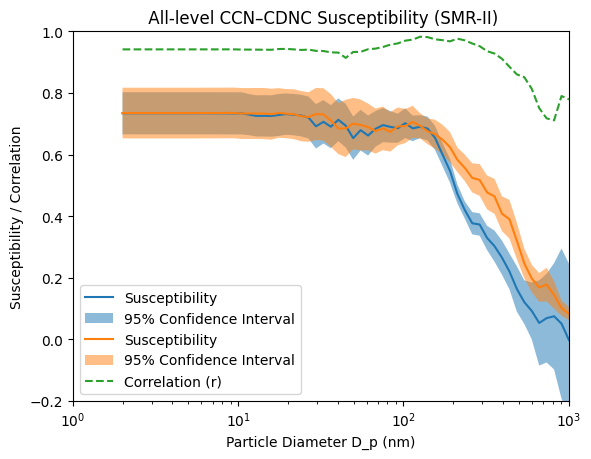

In [17]:
plt.plot(radii*2, reg_ds['slope'].sel(station = 'SMR-II'), label = 'Susceptibility')
plt.fill_between(radii*2,
                 reg_ds['slope'].sel(station = 'SMR-II')-1.98*reg_ds['std_err'].sel(station = 'SMR-II'),
                 reg_ds['slope'].sel(station = 'SMR-II')+1.98*reg_ds['std_err'].sel(station = 'SMR-II'),
                 alpha = 0.5, label = '95% Confidence Interval')
plt.plot(radii*2, reg_ds_scaledBins['slope'].sel(station = 'SMR-II'), label = 'Susceptibility')
plt.fill_between(radii*2,
                 reg_ds_scaledBins['slope'].sel(station = 'SMR-II')-1.98*reg_ds_scaledBins['std_err'].sel(station = 'SMR-II'),
                 reg_ds_scaledBins['slope'].sel(station = 'SMR-II')+1.98*reg_ds_scaledBins['std_err'].sel(station = 'SMR-II'),
                 alpha = 0.5, label = '95% Confidence Interval')
plt.plot(radii*2, reg_ds_scaledBins['r_value'].sel(station = 'SMR-II'), '--', label = 'Correlation (r)')
plt.legend()
plt.title(" All-level CCN–CDNC Susceptibility (SMR-II)")
plt.xlabel('Particle Diameter D_p (nm)')
plt.ylabel('Susceptibility / Correlation')
plt.ylim([-0.2, 1])
plt.xlim([1,1000])
plt.xscale('log')

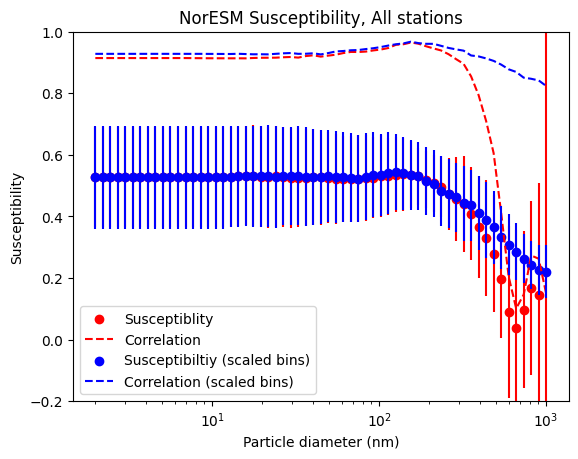

In [45]:
plt.scatter(reg_ds['radius']*2,reg_ds['slope'].mean('station'), label = 'Susceptiblity', c = 'red')
plt.errorbar(reg_ds['radius']*2,reg_ds['slope'].mean('station'), reg_ds['slope'].std('station'),    fmt='none', ecolor='red' )
plt.plot(reg_ds['radius']*2,reg_ds['r_value'].mean('station'), label = 'Correlation', c = 'red', ls = '--')

plt.scatter(reg_ds_scaledBins['radius']*2,reg_ds_scaledBins['slope'].mean('station'), label = 'Susceptibiltiy (scaled bins)', c= 'blue')
plt.errorbar(reg_ds_scaledBins['radius']*2,reg_ds_scaledBins['slope'].mean('station'), reg_ds_scaledBins['slope'].std('station'), fmt='none', ecolor='blue')
plt.plot(reg_ds_scaledBins['radius']*2,reg_ds_scaledBins['r_value'].mean('station'), label = 'Correlation (scaled bins)', ls =  '--', c= 'blue')

plt.xscale('log')
plt.ylim([-0.2,1])
plt.xlabel('Particle diameter (nm)')
plt.ylabel('Susceptibility')
plt.title('NorESM Susceptibility, All stations')
plt.legend()

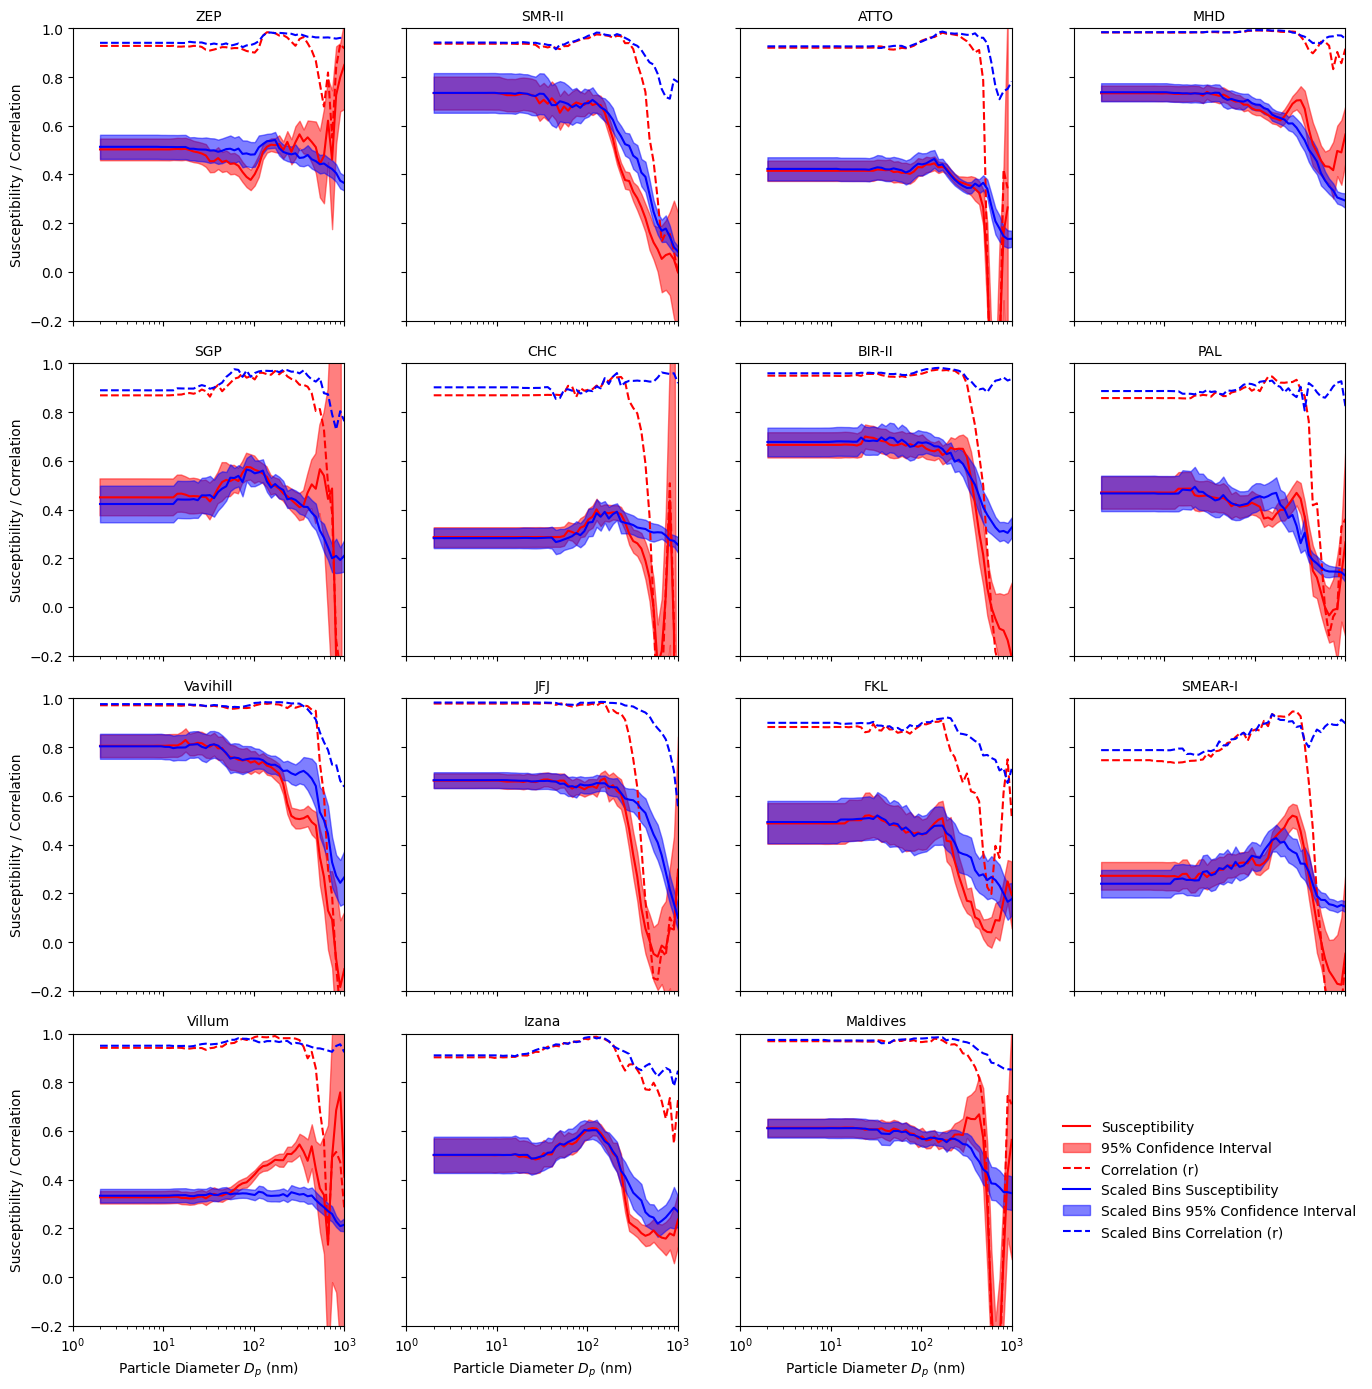

In [46]:
stations = reg_ds.station.values
n_stations = len(stations)

fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):

    ax = axes[i]

    slope = reg_ds['slope'].sel(station=station)
    std_err = reg_ds['std_err'].sel(station=station)
    r_val = reg_ds['r_value'].sel(station=station)
    slope1 = reg_ds_scaledBins['slope'].sel(station=station)
    std_err1 = reg_ds_scaledBins['std_err'].sel(station=station)
    r_val1 = reg_ds_scaledBins['r_value'].sel(station=station)

    ax.plot(radii * 2,
            slope,
            label='Susceptibility',
            color = 'red'
           )
    ax.fill_between(
        radii * 2,
        slope - 1.96 * std_err,
        slope + 1.96 * std_err,
        alpha=0.5,
        label='95% Confidence Interval',
        color = 'red'
    )
    ax.plot(
        radii * 2,
        r_val,
        '--',
        label='Correlation (r)',
        color = 'red'
    )


    ax.plot(radii * 2, slope1, label='Scaled Bins Susceptibility', color = 'blue')
    ax.fill_between(
        radii * 2,
        slope1 - 1.96 * std_err1,
        slope1 + 1.96 * std_err1,
        alpha=0.5,
        label='Scaled Bins 95% Confidence Interval', color = 'blue'
    )
    ax.plot(
        radii * 2,
        r_val1,
        '--',
        label='Scaled Bins Correlation (r)', color = 'blue'
    )

    ax.set_title(station, fontsize=10)
    ax.set_xscale('log')
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0.2, 1])

# --- Last panel used only for legend ---
legend_ax = axes[-1]
legend_ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(
    handles,
    labels,
    loc='center',
    frameon=False,
    fontsize=10
)

# Axis labels (only on outer edges)
for ax in axes[12:16]:
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')

for ax in axes[::4]:
    ax.set_ylabel('Susceptibility / Correlation')

plt.tight_layout()
plt.show()

In [12]:
from scipy import stats

n_bins = len(bins) - 1

for l in range(len(ds.lev)):
    print(f"Level {l}/{len(ds.lev)}")
    for s, station in enumerate(stations):

        # Pull (time, radius) slices for this station+level — two 2D arrays
        CCN_sl  = CCN_all['CCN'].sel(station=station).isel(lev=l).values   # (time, radius)
        CDNC_sl = CCN_all['CDNC'].sel(station=station).isel(lev=l).values  # (time,)

        for r in range(len(radii)):
            ccn  = CCN_sl[:, r]
            cdnc = CDNC_sl

            # Skip sparse slices early (cheap check)
            if np.sum(ccn > 1) < 2:
                continue

            # Digitize this radius slice
            bidx = np.clip(np.digitize(ccn, bins) - 1, 0, n_bins - 1)

            # Vectorized bin means using np.bincount (much faster than groupby_bins)
            x_means = np.full(n_bins, np.nan)
            y_means = np.full(n_bins, np.nan)
            for b in range(n_bins):
                sel = bidx == b
                if sel.sum() > 0:
                    x_means[b] = np.nanmean(ccn[sel])
                    y_means[b] = np.nanmean(cdnc[sel])

            x = np.log10(x_means)
            y = np.log10(y_means)
            mask = np.isfinite(x) & np.isfinite(y)
            if mask.sum() < 2:
                continue

            slope, intercept, r_value, p_value, std_err = stats.linregress(x[mask], y[mask])

            reg_ds_lev["slope"].loc[{"station": station, "radius": radii[r], "level": lev[l]}]   = slope
            reg_ds_lev["r_value"].loc[{"station": station, "radius": radii[r], "level": lev[l]}] = r_value
            reg_ds_lev["std_err"].loc[{"station": station, "radius": radii[r], "level": lev[l]}] = std_err

Level 0/32
Level 1/32


IndexError: boolean index did not match indexed array along axis 0; size of axis is 8761 but size of corresponding boolean axis is 61

In [31]:
stations = CCN_all.station.values
lev = CCN_all.where(CCN_all.CDNC.notnull, drop = True).lev.values
bins = np.logspace(0, 4, 101)  # 10^0=1, 10^4=10000'
# Pre-allocate Dataset
reg_ds_lev = xr.Dataset(
    data_vars={
        "slope":   (("station", "radius", 'level'), np.full((len(stations), len(radii), len(lev)), np.nan)),
        "r_value": (("station", "radius", 'level'), np.full((len(stations), len(radii), len(lev)), np.nan)),
        "std_err": (("station", "radius", 'level'), np.full((len(stations), len(radii), len(lev)), np.nan)),
    },
    coords={
        "station": stations,
        "radius": radii,
        "level": lev
    }
)
reg_ds_lev = xr.open_dataset('/share/pech2273/NorESM_Susceptibility_By_level.nc')
Downloaded = True
# Loop over stations and radii and level
if Downloaded == False:
    for l in range(len(lev)):
        print(l)
        for s, station in enumerate(stations):
            for r in range(len(radii)):
                
                CCN_slice = CCN_all['CCN'].sel(station=station).isel(radius=r, lev = l)
                CDNC_slice = CCN_all['CDNC'].sel(station=station).isel(lev = l)
                if CCN_slice.where(CCN_slice > 1).count() < 2:
                    continue
                # Bin by CCN
                CCN_binned = CCN_slice.groupby_bins(CCN_slice, bins).mean()
                CDNC_binned = CDNC_slice.groupby_bins(CCN_slice, bins).mean()
        
                x = np.log10(CCN_binned.values)
                y = np.log10(CDNC_binned.values)
        
                mask = np.isfinite(x) & np.isfinite(y)
        
                if mask.sum() < 2:
                    continue  # avoid linregress crash
        
                slope, intercept, r_value, p_value, std_err = stats.linregress(
                    x[mask], y[mask]
                )
        
                # Assign into Dataset
                reg_ds_lev["slope"][s, r, l] = slope
                reg_ds_lev["r_value"][s, r, l] = r_value
                reg_ds_lev["std_err"][s, r, l] = std_err


In [36]:
lev = CCN_all.where(CCN_all.CDNC.notnull, drop = True).lev.values


In [37]:
lev

array([379.10090387, 445.9925741 , 524.68717471, 609.77869481,
       691.38943031, 763.40448111, 820.85836865, 859.53476653,
       887.02024892, 912.64454694, 936.19839847, 957.48547954,
       976.32540739, 992.55609512])

In [39]:
stations = CCN_all.station.values
# Pre-allocate Dataset
reg_ds_lev_ScaledBins = xr.Dataset(
    data_vars={
        "slope":   (("station", "radius", 'level'), np.full((len(stations), len(radii), len(lev)), np.nan)),
        "r_value": (("station", "radius", 'level'), np.full((len(stations), len(radii), len(lev)), np.nan)),
        "std_err": (("station", "radius", 'level'), np.full((len(stations), len(radii), len(lev)), np.nan)),
    },
    coords={
        "station": stations,
        "radius": radii,
        "level": lev
    }
)

Downloaded = False
# Loop over stations and radii and level
if Downloaded == False:
    for l, level in enumerate(lev):
        print(l)
        for s, station in enumerate(stations):
            for r in range(len(radii)):
                
                CCN_slice = CCN_all['CCN'].sel(station=station, lev = level).isel(radius = r)
                CDNC_slice = CCN_all['CDNC'].sel(station=station, lev = level)
                if CCN_slice.where(CCN_slice > 1).count() < 2:
                    continue
                # Bin by CCN
                bins = np.logspace(np.log10(CCN_slice.min().values), np.log10(CCN_slice.max().values), 101)
                CCN_binned = CCN_slice.groupby_bins(CCN_slice, bins).mean()
                CDNC_binned = CDNC_slice.groupby_bins(CCN_slice, bins).mean()
        
                x = np.log10(CCN_binned.values)
                y = np.log10(CDNC_binned.values)
        
                mask = np.isfinite(x) & np.isfinite(y)
        
                if mask.sum() < 2:
                    continue  # avoid linregress crash
        
                slope, intercept, r_value, p_value, std_err = stats.linregress(
                    x[mask], y[mask]
                )
        
                # Assign into Dataset
                reg_ds_lev_ScaledBins["slope"][s, r, l] = slope
                reg_ds_lev_ScaledBins["r_value"][s, r, l] = r_value
                reg_ds_lev_ScaledBins["std_err"][s, r, l] = std_err


0
1
2
3
4
5
6
7
8
9
10
11
12
13


In [ ]:
reg_ds_lev = reg_ds_lev.compute()
reg_ds_lev
#reg_ds_lev.to_netcdf('/share/pech2273/NorESM_Susceptibility_By_level.nc')

In [ ]:
plt.plot(reg_ds_lev['radius']*2, reg_ds_lev['slope'].sel(station = 'SMR-II').isel(level = -3), label = 'Susceptibility')
plt.fill_between(reg_ds_lev['radius']*2,
                 reg_ds_lev['slope'].sel(station = 'SMR-II').isel(level = -3)-1.98*reg_ds_lev['std_err'].sel(station = 'SMR-II').isel(level = -3),
                 reg_ds_lev['slope'].sel(station = 'SMR-II').isel(level = -3)+1.98*reg_ds_lev['std_err'].sel(station = 'SMR-II').isel(level = -3),
                 alpha = 0.5, label = '95% Confidence Interval')
plt.plot(reg_ds_lev['radius']*2, reg_ds_lev['r_value'].sel(station = 'SMR-II').isel(level = -3), '--', label = 'Correlation (r)')
plt.legend()
plt.title(f'CCN–CDNC Susceptibility (SMR-II) \n Height {height.sel(station = 'SMR-II').isel(lev = -3).values:.2f} m')
plt.xlabel('Particle Diameter D_p (nm)')
plt.ylabel('Susceptibility / Correlation')
plt.ylim([-0.2, 1])
plt.xlim([1,1000])
plt.xscale('log')

In [ ]:
np.flip(height.sel(station = 'SMR-II').values)
reg_ds_lev['slope'].sel(station = 'SMR-II')
reg_ds_lev.isel(level = slice(None, None, -1))

TypeError: Dimensions of C (32, 31) are incompatible with X (31) and/or Y (14); see help(pcolormesh)

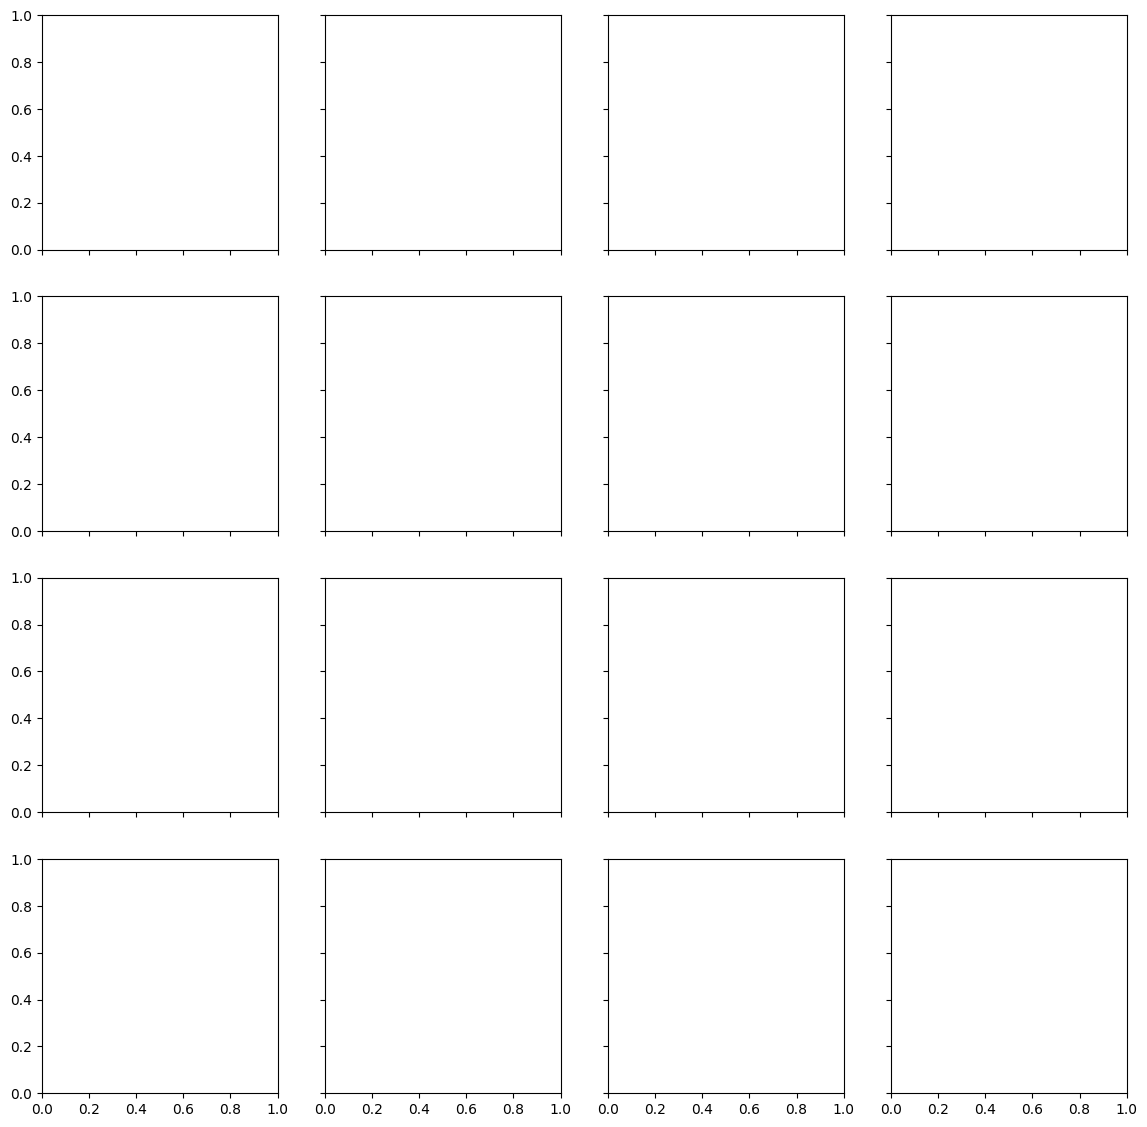

In [47]:
import numpy as np
import matplotlib.pyplot as plt

stations = reg_ds.station.values
n_stations = len(stations)

# --- Create figure and axes ---
fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

# --- Loop over stations ---
for i, station in enumerate(stations):
    ax = axes[i]

    mesh = ax.pcolormesh(
        reg_ds_lev['radius'] * 2,
        height.sel(station=station),
        reg_ds_lev['slope'].sel(station=station).T,
        shading='nearest',
        vmin=0,
        vmax=1,
        cmap='RdYlGn'
    )

    ax.set_title(station, fontsize=10)
    ax.set_xscale('log')
    ax.set_xlim(2, 1000)
    ax.set_ylim(180, 6000)

# --- Turn off unused panels ---
for j in range(i + 1, len(axes)):
    axes[j].axis('off')



# --- Axis labels on outer edges only ---
for ax in axes[12:16]:
    ax.set_xlabel('Particle Diameter (nm)')

for ax in axes[::4]:
    ax.set_ylabel('Height (m)')

# --- Figure title and layout ---
fig.suptitle(
    'Susceptibility with height and particle diameter',
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 0.95, 0.96])
plt.show()


In [52]:
reg_ds_lev_ScaledBins['slope'].sel(station='ATTO').isel(radius = 1)

<xarray.DataArray 'slope' (level: 14)> Size: 112B
array([ 0.58929942,  0.61275424,  0.36921511,  0.42620559,  0.58737107,
        0.71347711,  0.77131786,         nan,         nan,         nan,
               nan,         nan,         nan, -0.67204118])
Coordinates:
    station  <U8 32B 'ATTO'
    radius   float64 8B 1.109
  * level    (level) float64 112B 379.1 446.0 524.7 609.8 ... 957.5 976.3 992.6

In [54]:
reg_ds_lev['slope'].sel(station='ATTO').isel(radius = 1).values

array([        nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,  0.58906456,  0.64188329,
        0.37015579,  0.42987334,  0.5671041 ,  0.72637017,  0.75844103,
               nan,         nan,         nan,         nan,         nan,
               nan, -0.8275376 ])

In [51]:
height.sel(station='ATTO').values

array([ 127.40299,  273.4531 ,  445.89713,  643.99023,  867.2151 ,
       1115.078  , 1387.0787 , 1781.5864 , 2395.2185 , 3219.7466 ,
       4247.89   , 5454.107  , 6724.4263 , 7956.8096 ], dtype=float32)

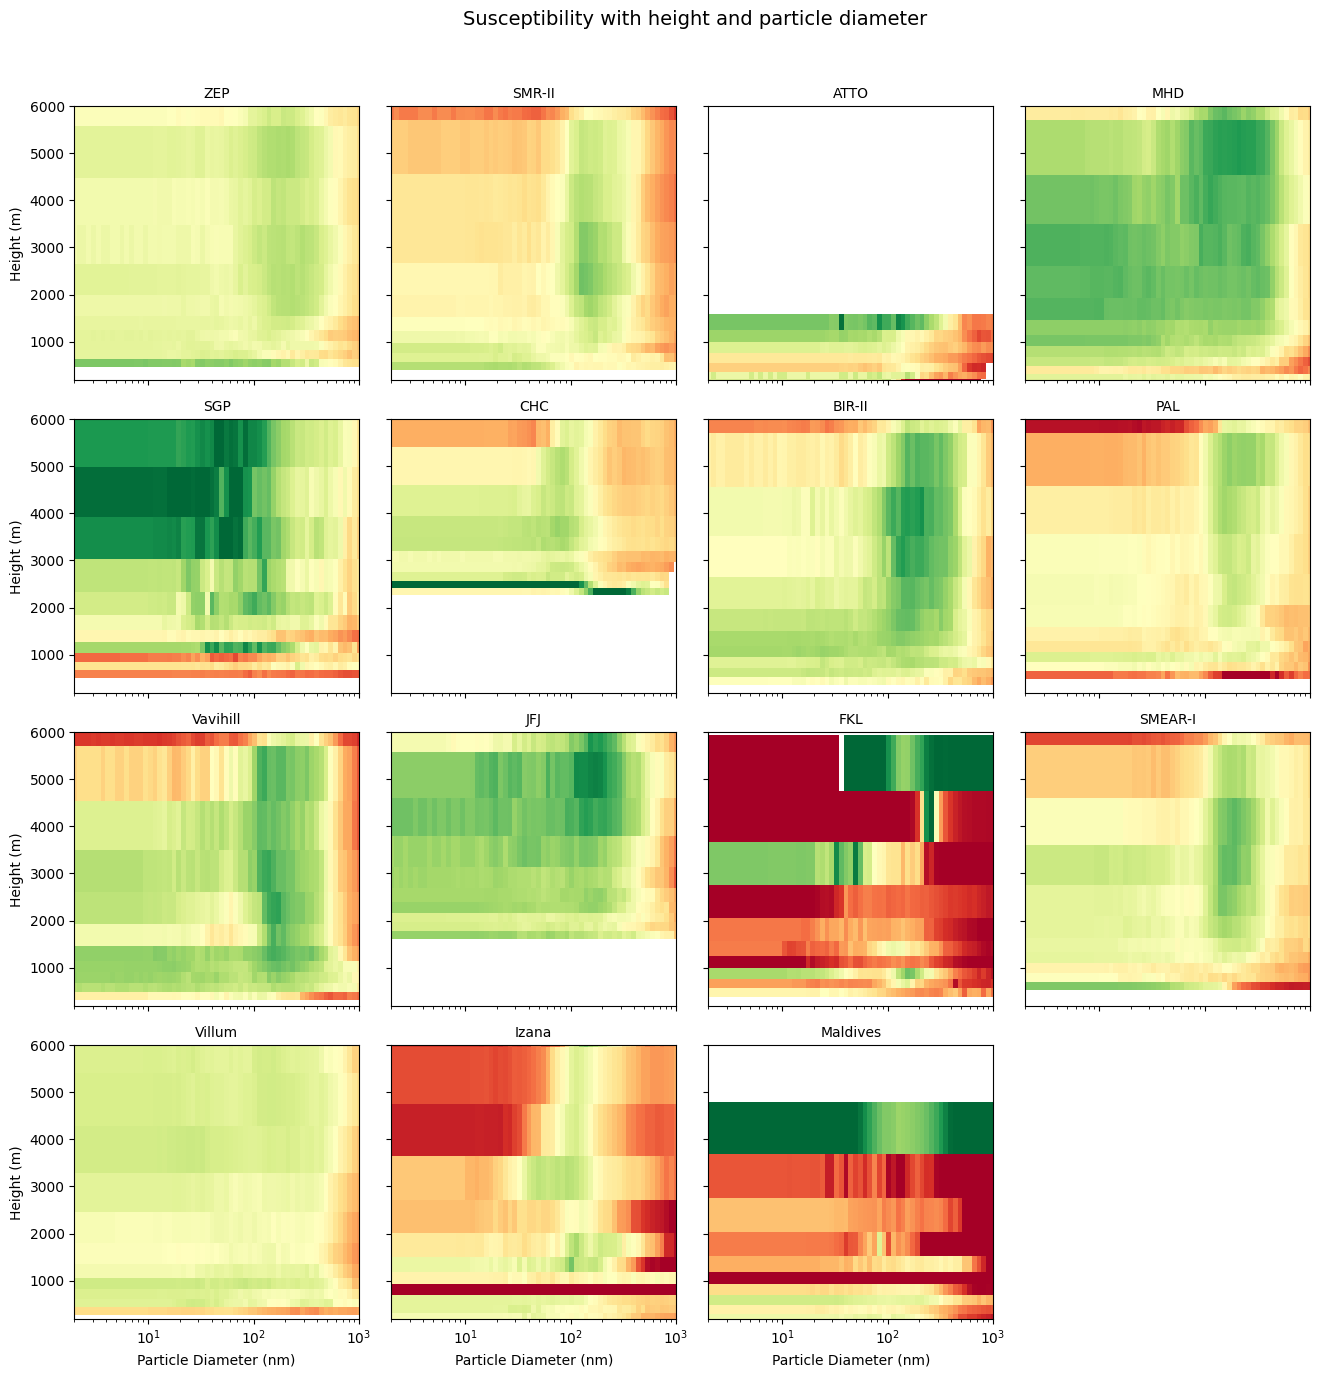

In [43]:
import numpy as np
import matplotlib.pyplot as plt
height = ds['Z3'].mean('time').isel(lev = slice(-1,-15,-1))
stations = reg_ds.station.values
n_stations = len(stations)

# --- Create figure and axes ---
fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

# --- Loop over stations ---
for i, station in enumerate(stations):
    ax = axes[i]

    mesh = ax.pcolormesh(
        reg_ds_lev_ScaledBins['radius'] * 2,
        height.sel(station=station),
        reg_ds_lev_ScaledBins['slope'].sel(station=station).T,
        shading='nearest',
        vmin=0,
        vmax=1,
        cmap='RdYlGn'
    )

    ax.set_title(station, fontsize=10)
    ax.set_xscale('log')
    ax.set_xlim(2, 1000)
    ax.set_ylim(180, 6000)

# --- Turn off unused panels ---
for j in range(i + 1, len(axes)):
    axes[j].axis('off')



# --- Axis labels on outer edges only ---
for ax in axes[12:16]:
    ax.set_xlabel('Particle Diameter (nm)')

for ax in axes[::4]:
    ax.set_ylabel('Height (m)')

# --- Figure title and layout ---
fig.suptitle(
    'Susceptibility with height and particle diameter',
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 0.95, 0.96])
plt.show()


In [70]:
ds['WSUB']

<xarray.DataArray 'WSUB' (station: 15, time: 8761, lev: 32)> Size: 17MB
dask.array<open_dataset-WSUB, shape=(15, 8761, 32), dtype=float32, chunksize=(15, 8761, 32), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 70kB 2012-01-02 ... 2015-01-01
  * station  (station) <U8 480B 'ZEP' 'SMR-II' 'ATTO' ... 'Izana' 'Maldives'
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
Attributes: (12/15)
    mdims:            1
    units:            m/s
    long_name:        Diagnostic sub-grid vertical velocity
    pressure_coords:  False
    raw_data_path:    /proj/bolinc/users/x_sarbl/noresm_archive
    model:            NorESM
    ...               ...
    case_name_nice:   OsloAero_prcp2szdst_f19_f19_noresmv211_corr
    isSectional:      False
    from_time:        2012-01-01
    to_time:          2012-02-01
    startyear:        2012
    endyear:          2012

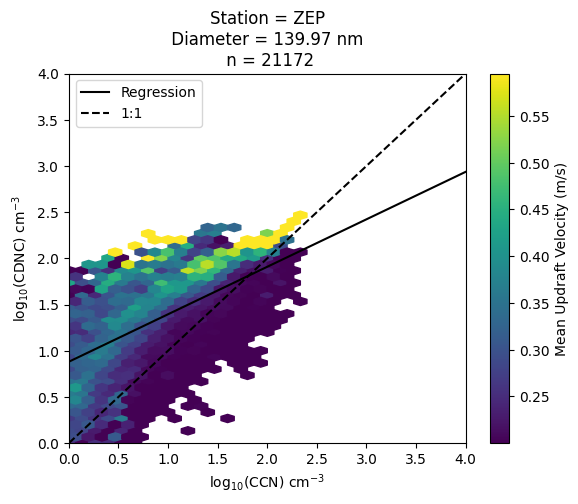

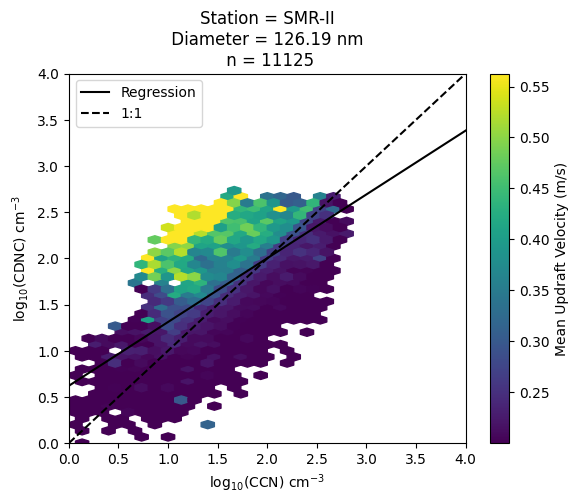

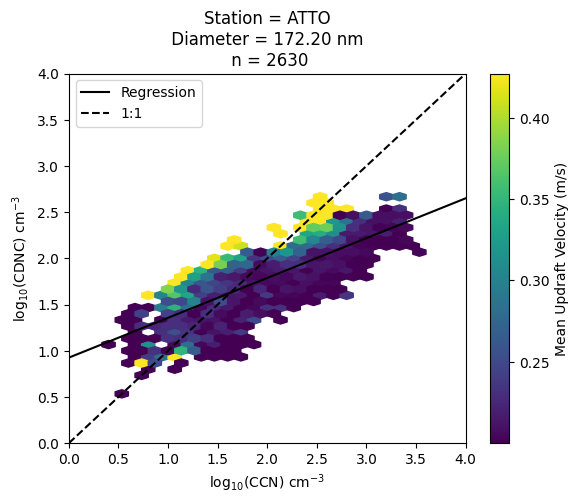

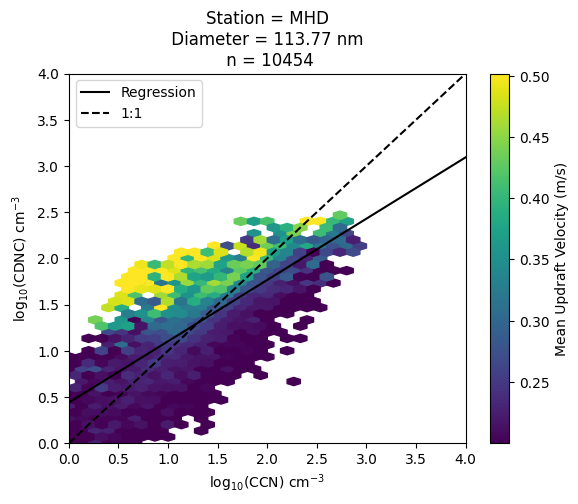

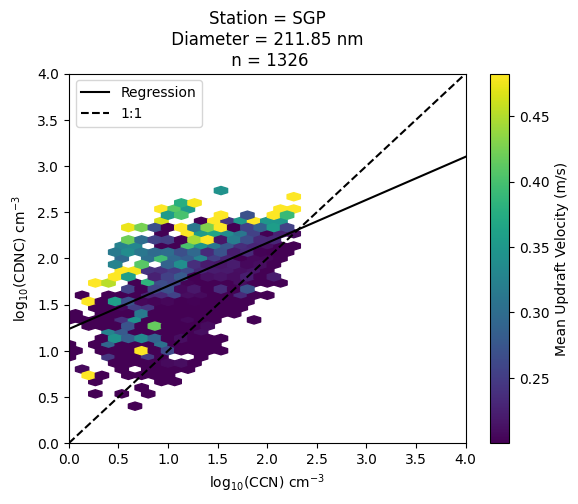

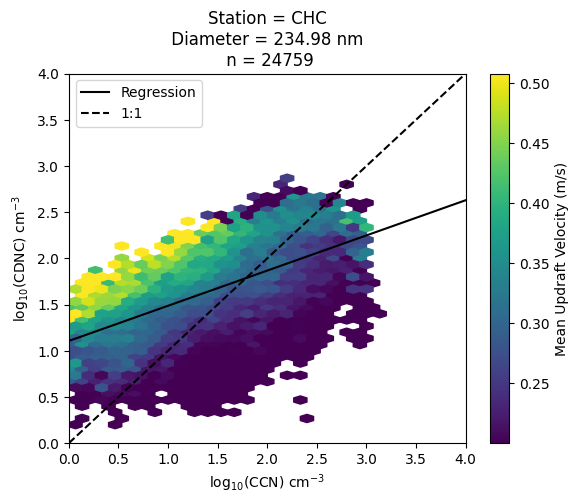

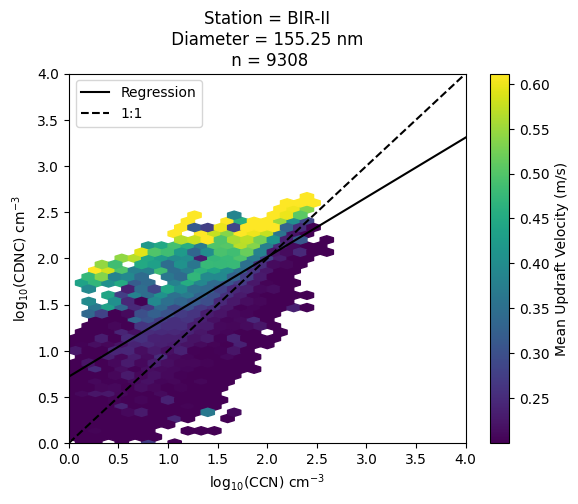

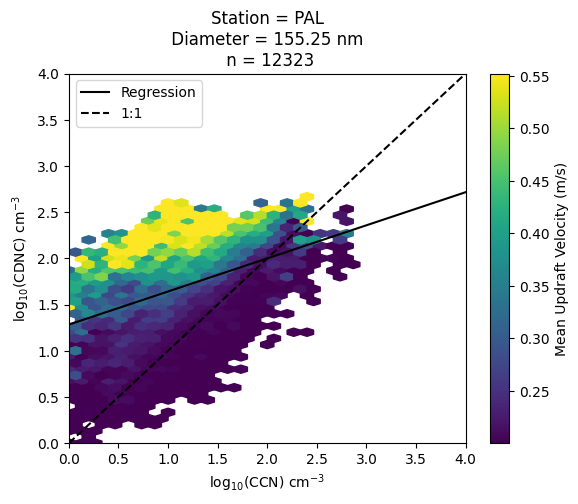

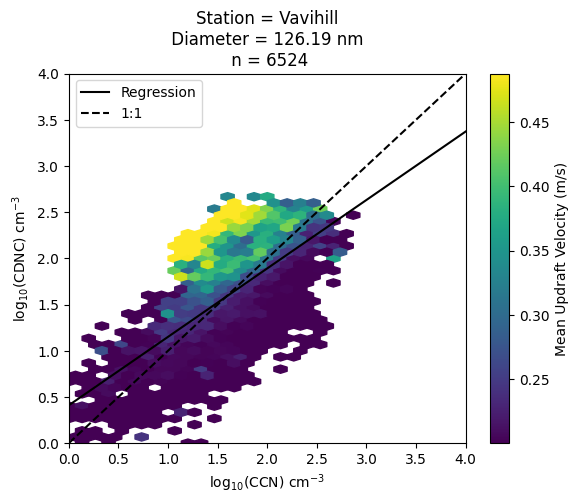

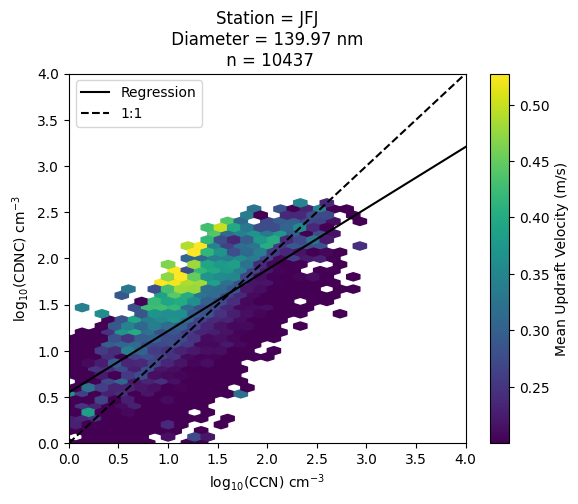

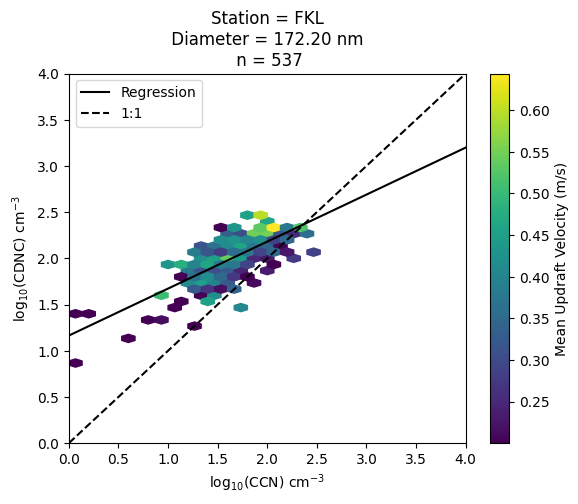

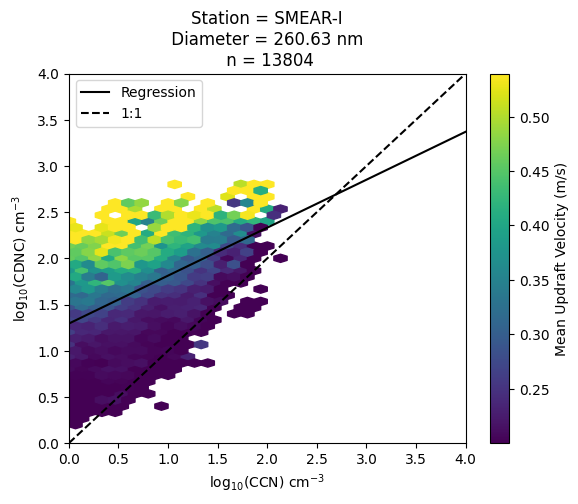

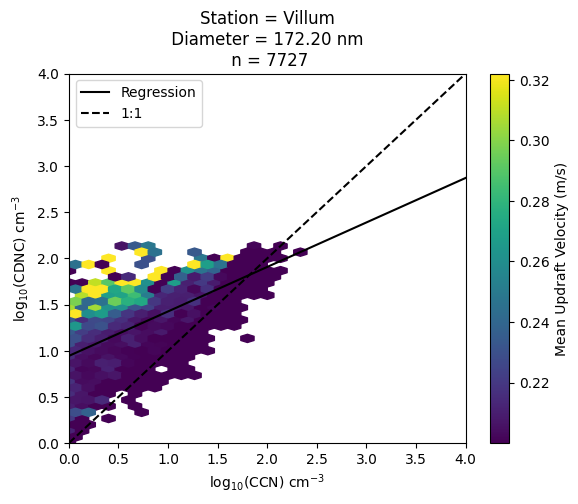

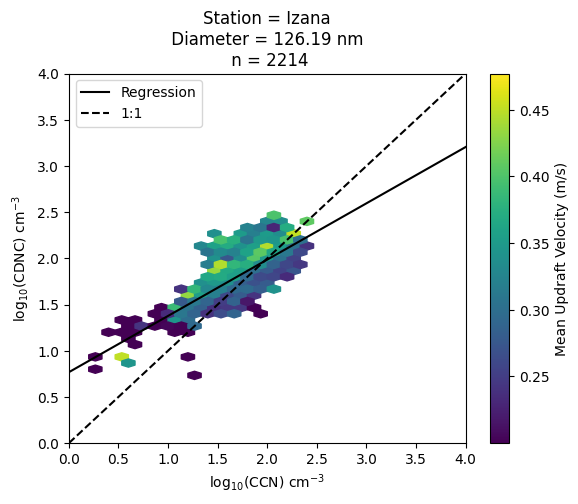

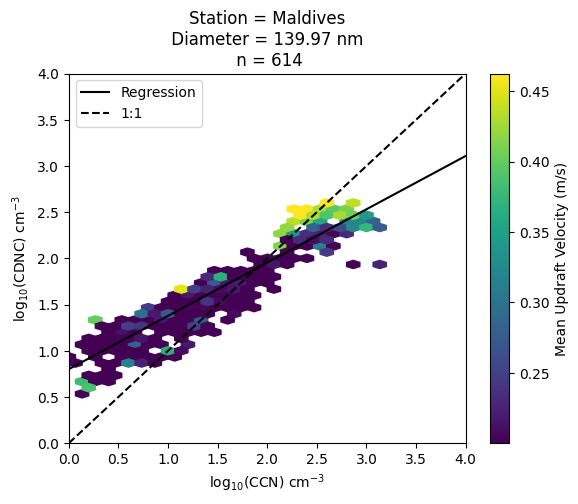

In [100]:
for station in reg_ds.station:
    r = reg_ds['r_value'].sel(station=station).argmax().values
    log_x = np.log10(CCN_all['CCN'].sel(station=station).isel(radius=r).where(CCN_all['CDNC'].sel(station=station) > 0, drop=True)).compute().values.flatten()
    log_y = np.log10(CCN_all['CDNC'].sel(station=station).where(CCN_all['CDNC'].sel(station=station) > 0, drop=True)).compute().values.flatten()
    wsub = ds['WSUB'].sel(station=station).where(CCN_all['CDNC'].sel(station=station) > 0, drop=True).compute().values.flatten()
    
    # Joint mask — drop where ANY of the three are NaN
    mask = np.isfinite(log_x) & np.isfinite(log_y) & np.isfinite(wsub)
    log_x, log_y, wsub = log_x[mask], log_y[mask], wsub[mask]
    
    hb = plt.hexbin(
        log_x,
        log_y,
        C=wsub,
        reduce_C_function=np.mean,
        cmap='viridis',
        gridsize=[30, 30],
        vmin=float(np.quantile(wsub, 0.05)),
        vmax=float(np.quantile(wsub, 0.95)),
        mincnt=1,
        extent=[0, 4, 0, 4],
    )

    plt.colorbar(hb, label='Mean Updraft Velocity (m/s)')

    x = np.linspace(0, 4, 10)
    y = x * reg_ds['slope'].sel(station=station).isel(radius=r).values + reg_ds['intercept'].sel(station=station).isel(radius=r).values
    plt.plot(x, y, 'k-', label='Regression')
    plt.plot([0, 4], [0, 4], 'k--', label='1:1')

    plt.title(f'Station = {station.values}\n Diameter = {reg_ds["radius"].isel(radius=reg_ds["r_value"].sel(station=station).argmax().values).values*2:.2f} nm \n n = {len(log_x)}')
    plt.xlim([0, 4])
    plt.ylim([0, 4])
    plt.xlabel('log$_{10}$(CCN) cm$^{-3}$')
    plt.ylabel('log$_{10}$(CDNC) cm$^{-3}$')
    plt.legend()

    plt.show()
    plt.style.use('default')


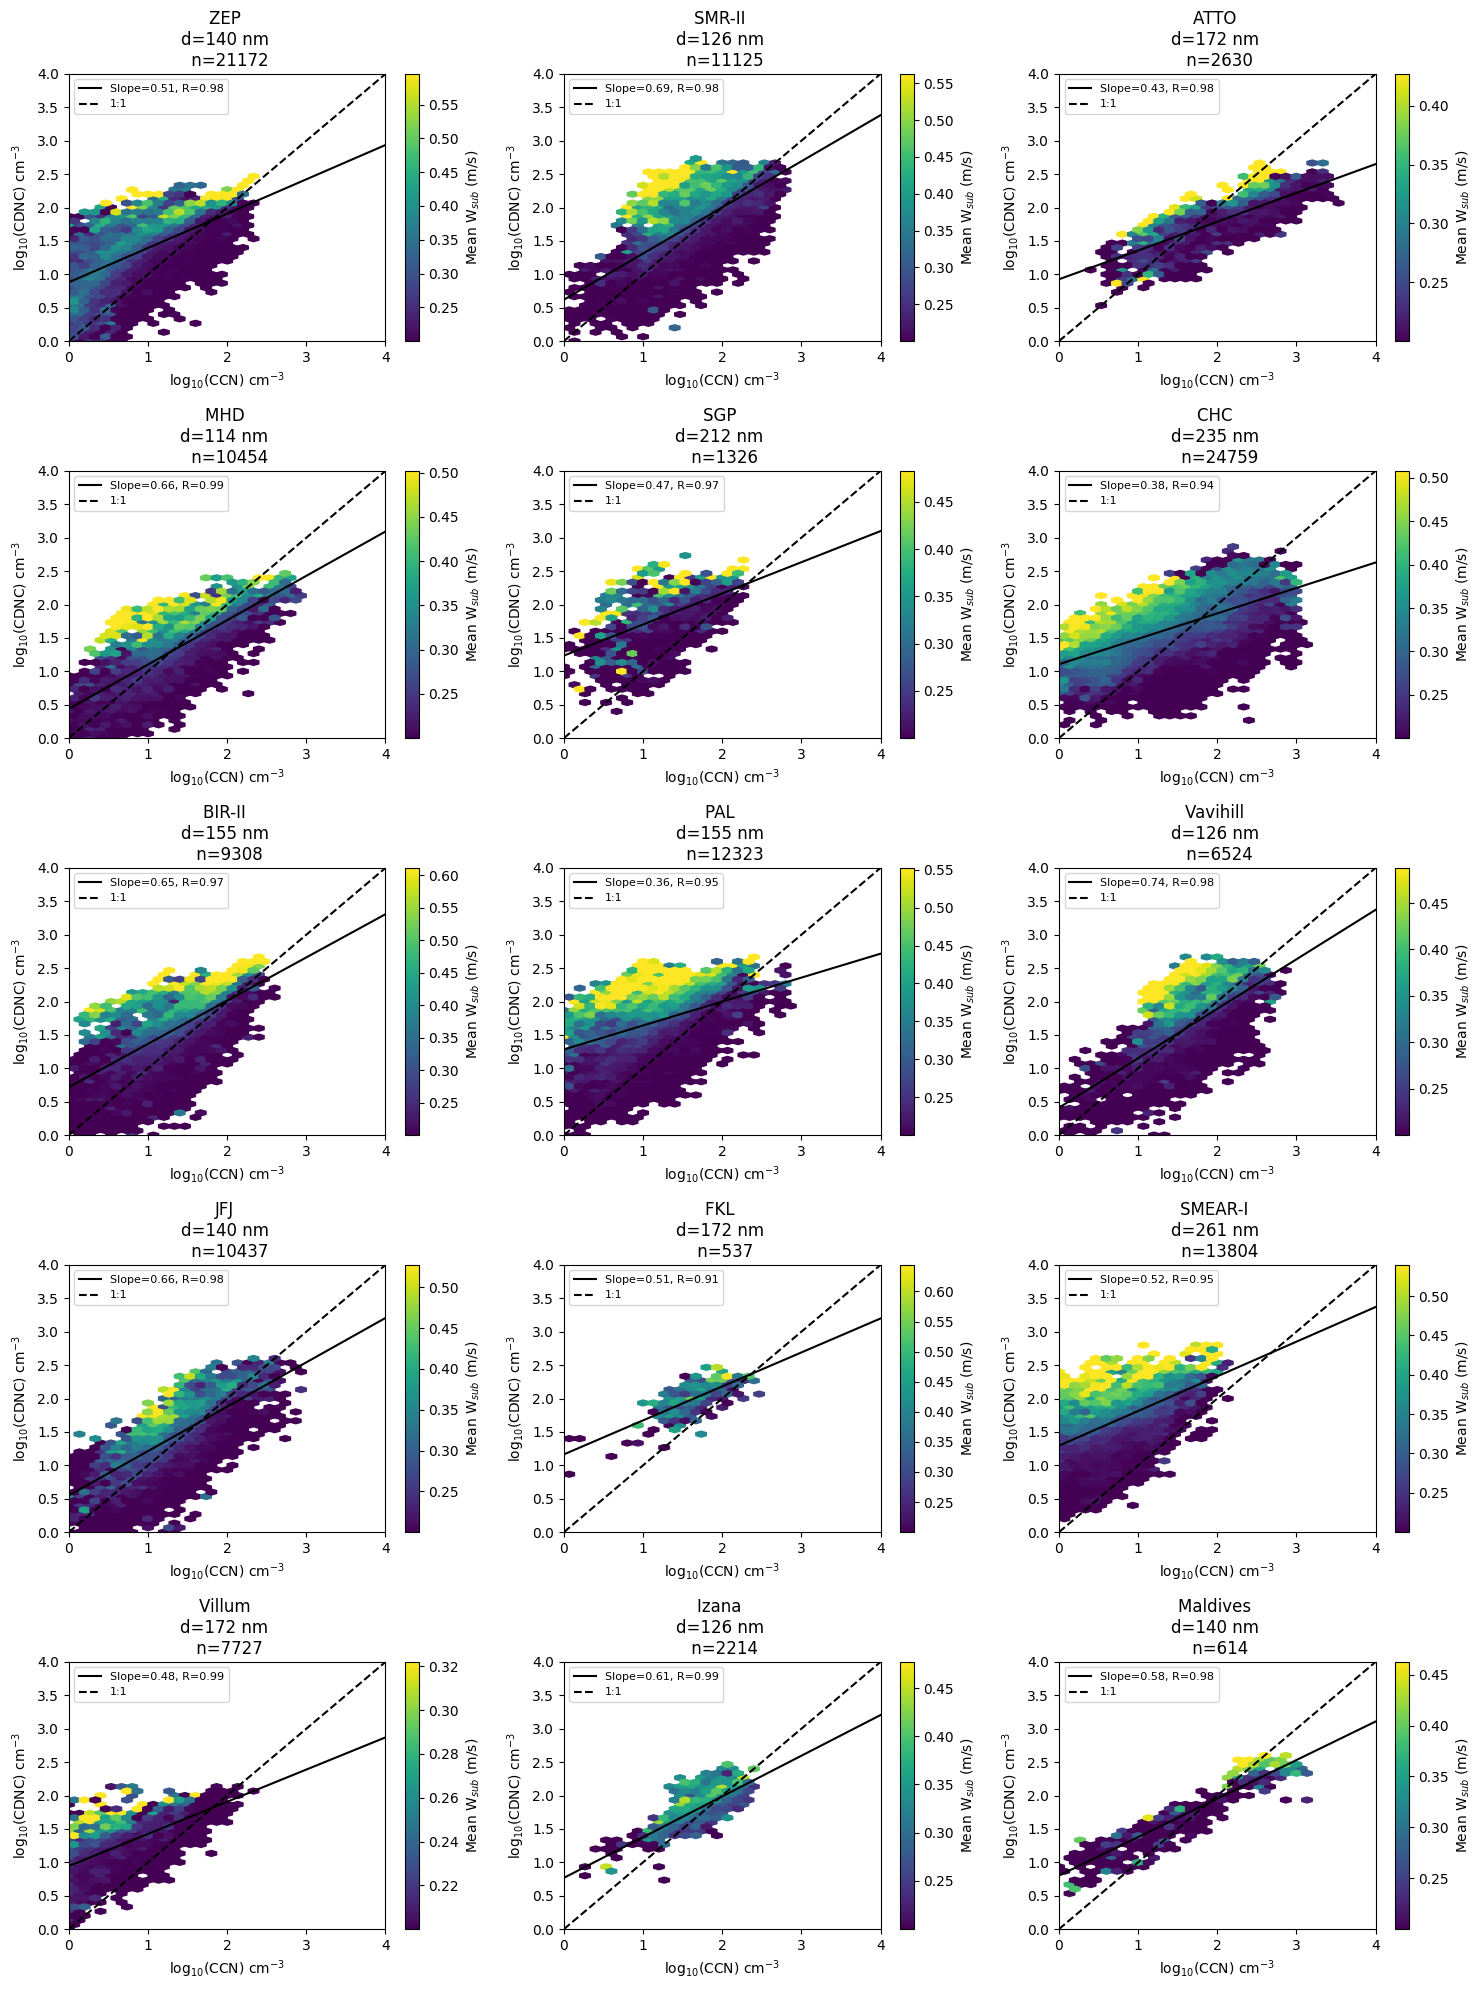

In [103]:
import math

stations = list(reg_ds.station)
n = len(stations)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for i, station in enumerate(stations):
    ax = axes[i]
    r = reg_ds['r_value'].sel(station=station).argmax().values
    log_x = np.log10(CCN_all['CCN'].sel(station=station).isel(radius=r).where(CCN_all['CDNC'].sel(station=station) > 0, drop=True)).compute().values.flatten()
    log_y = np.log10(CCN_all['CDNC'].sel(station=station).where(CCN_all['CDNC'].sel(station=station) > 0, drop=True)).compute().values.flatten()
    wsub = ds['WSUB'].sel(station=station).where(CCN_all['CDNC'].sel(station=station) > 0, drop=True).compute().values.flatten()

    mask = np.isfinite(log_x) & np.isfinite(log_y) & np.isfinite(wsub)
    log_x, log_y, wsub = log_x[mask], log_y[mask], wsub[mask]

    hb = ax.hexbin(
        log_x,
        log_y,
        C=wsub,
        reduce_C_function=np.mean,
        cmap='viridis',
        gridsize=[30, 30],
        vmin=float(np.quantile(wsub, 0.05)),
        vmax=float(np.quantile(wsub, 0.95)),
        mincnt=1,
        extent=[0, 4, 0, 4],
    )
    fig.colorbar(hb, ax=ax, label='Mean W$_{sub}$ (m/s)')

    x = np.linspace(0, 4, 10)
    slope = reg_ds['slope'].sel(station=station).isel(radius=r).values
    intercept = reg_ds['intercept'].sel(station=station).isel(radius=r).values
    rval = reg_ds['r_value'].sel(station=station).isel(radius=r).values
    y = x * slope + intercept

    ax.plot(x, y, 'k-', label=f'Slope={slope:.2f}, R={rval:.2f}')
    ax.plot([0, 4], [0, 4], 'k--', label='1:1')

    ax.set_xlim([0, 4])
    ax.set_ylim([0, 4])
    ax.set_xlabel('log$_{10}$(CCN) cm$^{-3}$')
    ax.set_ylabel('log$_{10}$(CDNC) cm$^{-3}$')
    ax.set_title(
        f'{station.values} \n'
        f'd={reg_ds["radius"].isel(radius=r).values*2:.0f} nm \n '
        f'n={len(log_x)}'
    )
    ax.legend(fontsize=8)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

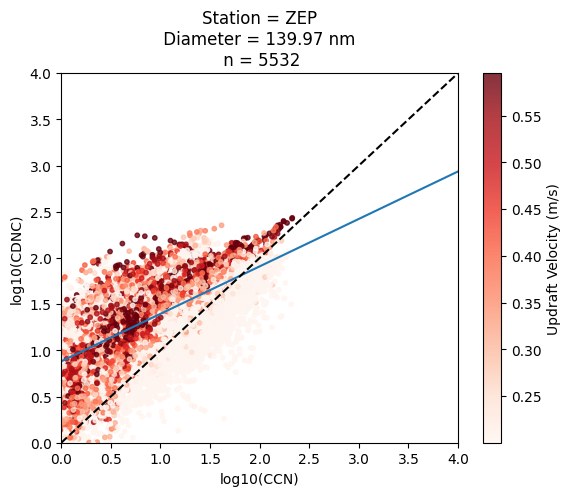

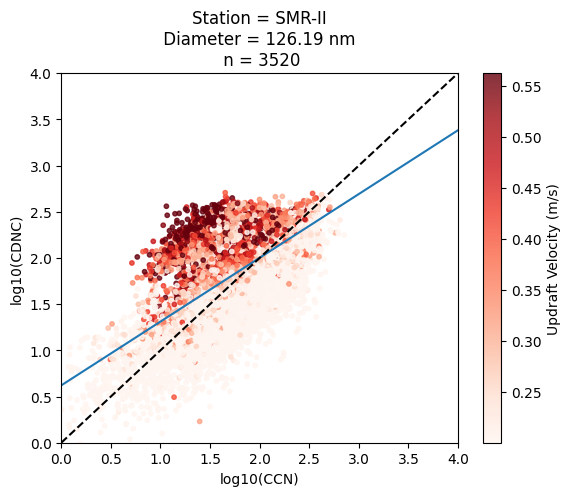

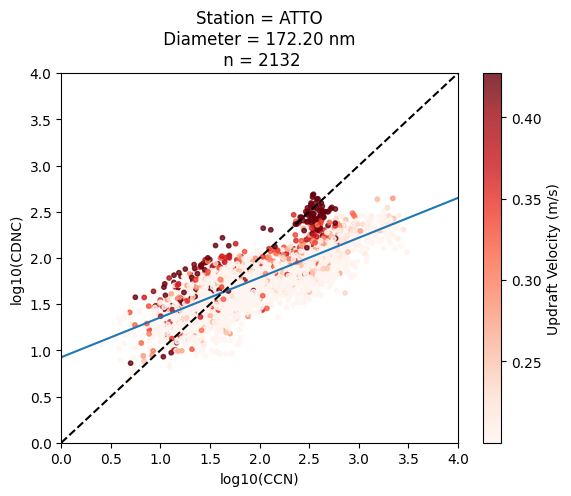

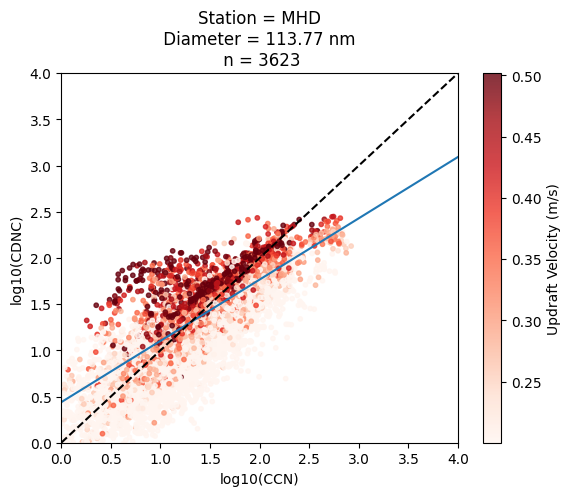

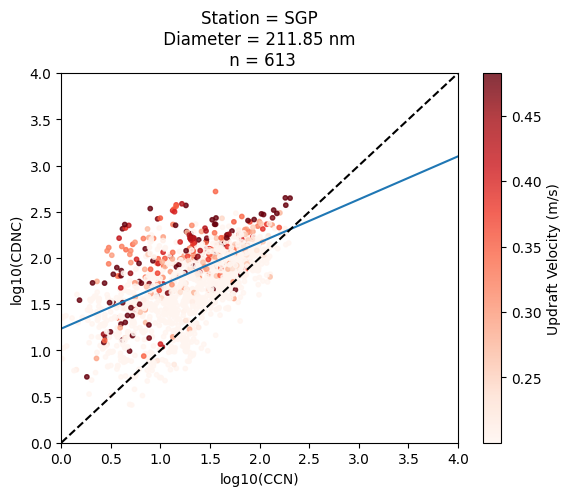

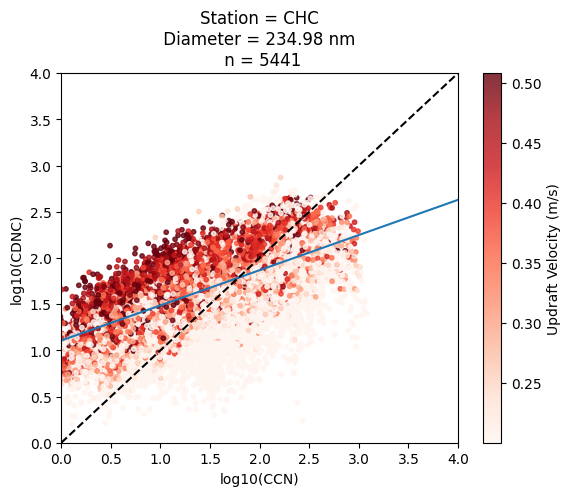

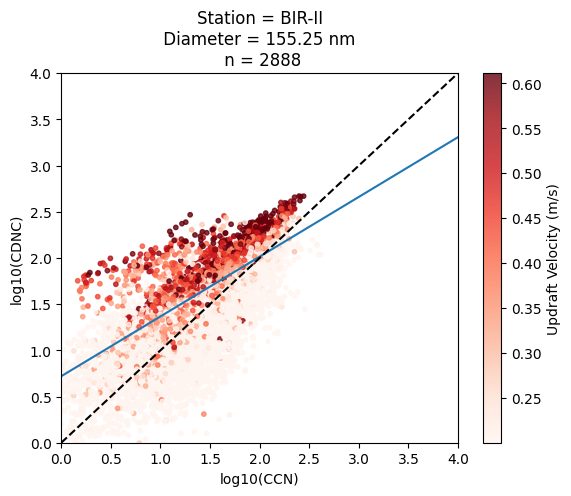

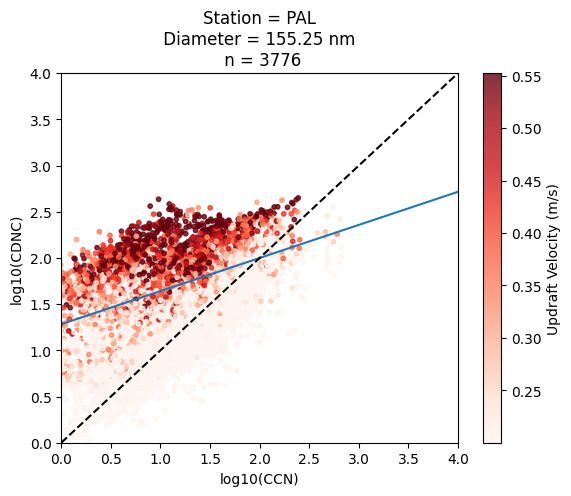

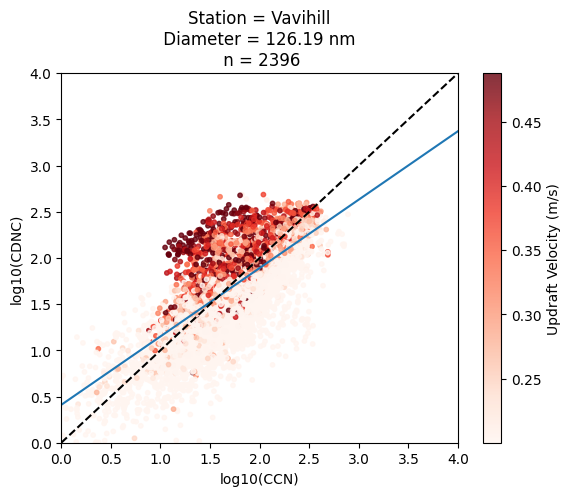

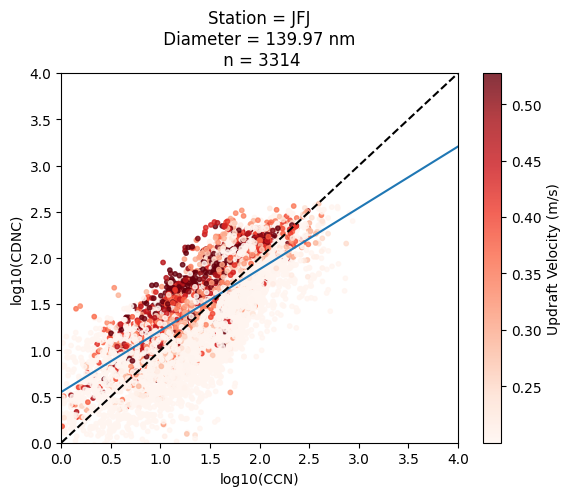

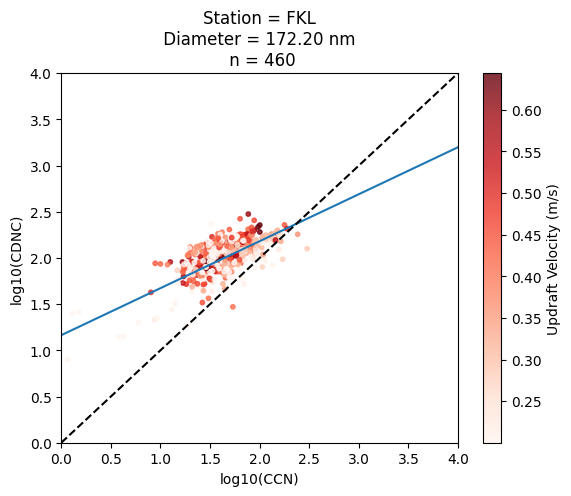

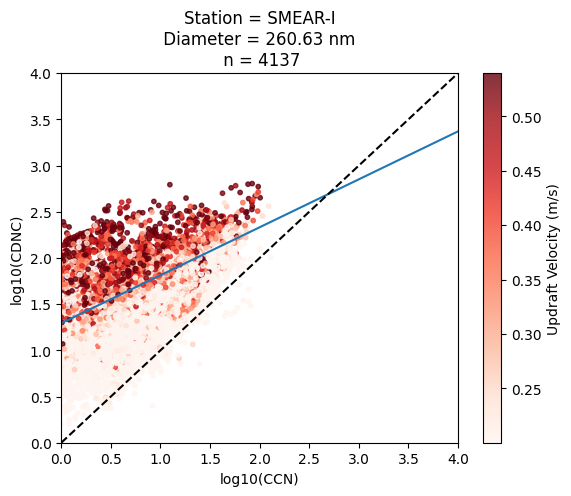

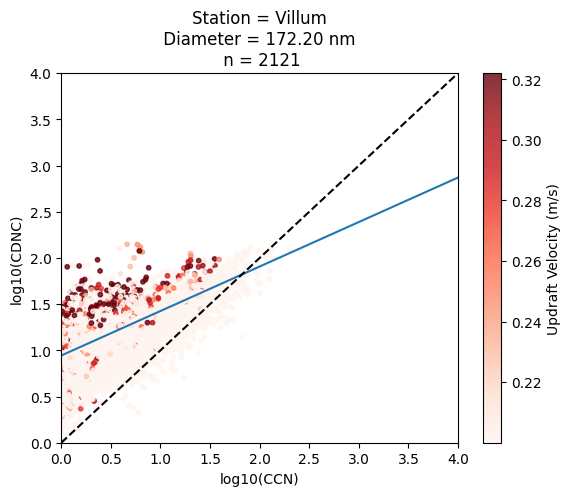

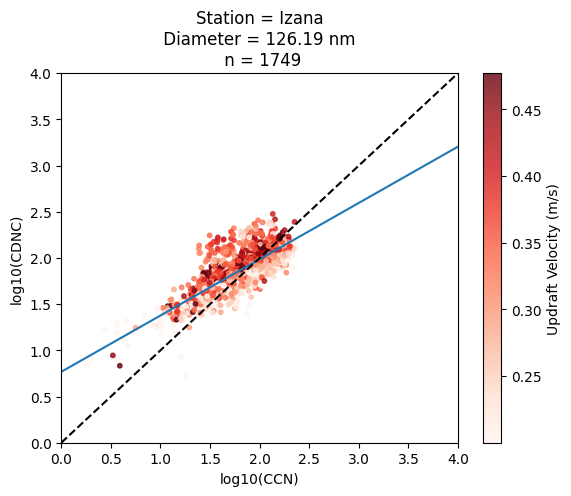

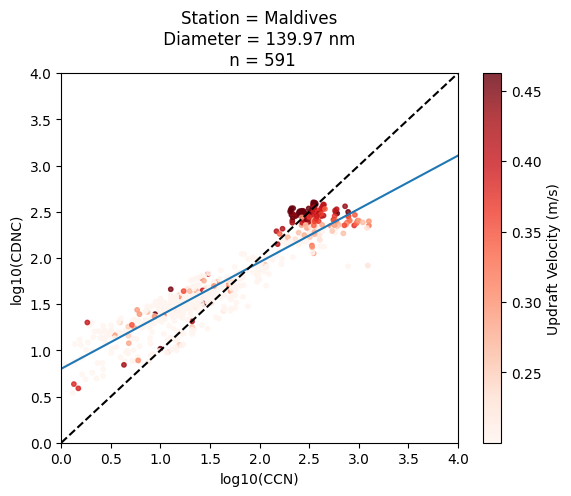

In [91]:

for station in reg_ds.station:
    r = reg_ds['r_value'].sel(station = station).argmax().values
    log_x = np.log10(CCN_all['CCN'].sel(station=station).isel(radius=r).where(CCN_all['CDNC'].sel(station = station)>0, drop = True))
    log_y = np.log10(CCN_all['CDNC'].sel(station=station).where(CCN_all['CDNC'].sel(station = station)>0, drop = True))


    wsub = ds['WSUB'].sel(station=station).where(CCN_all['CDNC'].sel(station=station) > 0, drop=True).compute()
    
    plt.scatter(
        log_x,
        log_y,
        c=wsub,
        cmap='Reds',
        norm=plt.Normalize(vmin=wsub.quantile(0.05), vmax=wsub.quantile(0.95)),  # robust colorscale
        alpha=0.8,
        s=10,
    )
    
    plt.colorbar(label='Updraft Velocity (m/s)')
    x = np.linspace(0,4,10)
    y = x*reg_ds['slope'].sel(station = station).isel(radius = r).values+reg_ds['intercept'].sel(station = station).isel(radius = r).values
    plt.plot(x,y )

    # Reference & formatting
    plt.title(f'Station = {station.values}\n Diameter = {reg_ds['radius'].isel(radius = reg_ds['r_value'].sel(station = station).argmax().values).values*2:.2f} nm \n n = {len(CCN_all['CCN'].sel(station=station).isel(radius=r).where(CCN_all['CDNC'].sel(station = station)>0, drop = True))}')
    plt.xlim([0, 4])
    plt.ylim([0, 4])
    plt.plot([0, 4], [0, 4], 'k--')
    
    plt.xlabel('log10(CCN)')
    plt.ylabel('log10(CDNC)')
    plt.show()

In [ ]:
stations = reg_ds.station.values
n_stations = len(stations)

fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):

    ax = axes[i]

    
    
    for r in np.arange(10,26,5):
        slope = reg_ds_lev['slope'].sel(station=station).isel(radius = r)
        ax.plot(slope, height.sel(station = station), label = f'Diameter = {reg_ds_lev['radius'][r].values*2:.2f} nm')

    ax.set_title(station, fontsize=10)
    ax.set_xlim([0,1])
    ax.set_ylim([0, 7500])

# --- Last panel used only for legend ---
legend_ax = axes[-1]
legend_ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(
    handles,
    labels,
    loc='center',
    frameon=False,
    fontsize=10
)

# Axis labels (only on outer edges)
for ax in axes[12:16]:
    ax.set_xlabel('Susceptiblity')

for ax in axes[::4]:
    ax.set_ylabel('Altitude (m)')

plt.tight_layout()
plt.show()



In [ ]:
stations = reg_ds.station.values

slope = reg_ds_lev['slope'].sel(station = 'SMR-II').sel(radius = 35, method='nearest')
std_err = reg_ds_lev['std_err'].sel(station = 'SMR-II').sel(radius = 35, method='nearest')
plt.plot(slope, height.sel(station = 'SMR-II'))
plt.fill_betweenx(height.sel(station = 'SMR-II'),
                  slope-1.96*std_err,
                  slope+1.96*std_err,
                  alpha = 0.2)

plt.title('NorESM: SMR-II Susceptibiltiy with Height', fontsize=10)
plt.xlim([0,1])
plt.ylim([0, 5500])

plt.xlabel('Susceptibiltiy')
plt.ylabel('Height (m)')

plt.tight_layout()
plt.show()



In [ ]:
stations = reg_ds.station.values
n_stations = len(stations)

fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):

    ax = axes[i]

    slope = reg_ds['slope'].sel(station=station)
    std_err = reg_ds['std_err'].sel(station=station)
    r_val = reg_ds['r_value'].sel(station=station)

    ax.plot(radii * 2, slope, label='Susceptibility')
    ax.fill_between(
        radii * 2,
        slope - 1.96 * std_err,
        slope + 1.96 * std_err,
        alpha=0.5,
        label='95% Confidence Interval'
    )
    ax.plot(
        radii * 2,
        r_val,
        '--',
        label='Correlation (r)'
    )

    ax.set_title(station, fontsize=10)
    ax.set_xscale('log')
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0.2, 1])

# --- Last panel used only for legend ---
legend_ax = axes[-1]
legend_ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(
    handles,
    labels,
    loc='center',
    frameon=False,
    fontsize=10
)

# Axis labels (only on outer edges)
for ax in axes[12:16]:
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')

for ax in axes[::4]:
    ax.set_ylabel('Susceptibility / Correlation')

plt.tight_layout()
plt.show()



In [ ]:
stations = reg_ds.station.values
n_stations = len(stations)

fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):

    ax = axes[i]

    intercept = reg_ds['intercept'].sel(station=station)
    std_err = reg_ds['std_err'].sel(station=station)
    r_val = reg_ds['r_value'].sel(station=station)

    ax.plot(radii * 2, intercept, label='Susceptibility Intercept')


    ax.set_title(station, fontsize=10)
    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlim([1, 1000])

# --- Last panel used only for legend ---
legend_ax = axes[-1]
legend_ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(
    handles,
    labels,
    loc='center',
    frameon=False,
    fontsize=10
)

# Axis labels (only on outer edges)
for ax in axes[12:16]:
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')

for ax in axes[::4]:
    ax.set_ylabel('Susceptibility Intercept')

plt.tight_layout()
plt.show()



In [ ]:
reg_ds = reg_ds.compute()
plt.scatter(reg_ds['radius']*2,reg_ds['slope'].mean('station'), label = 'Mean')
plt.errorbar(reg_ds['radius']*2,reg_ds['slope'].mean('station'), reg_ds['slope'].std('station'),    fmt='o',
    label='Mean ±1σ'
)
plt.xscale('log')
plt.ylim([-0.2,1])
plt.xlabel('Particle diameter (nm)')
plt.ylabel('Susceptibility')
plt.title('NorESM Susceptibility, All stations')
plt.legend()

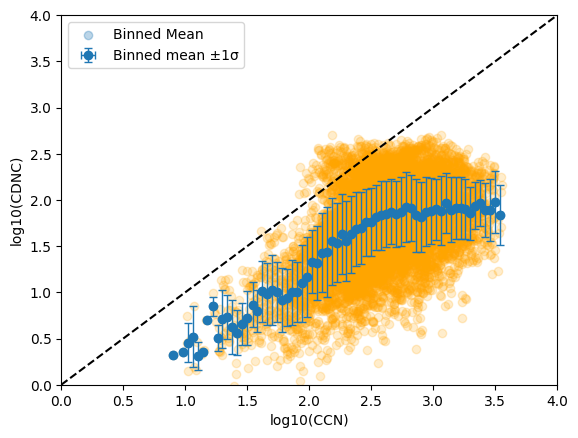

In [55]:
r = 23

Log_bins = np.linspace(0,4,101)
log_x = np.log10(CCN_all['CCN'].sel(station='SMR-II').isel(radius=r))
log_y = np.log10(CCN_all['CDNC'].sel(station='SMR-II'))
# Binned means
x_mean = log_x \
    .groupby_bins(log_x, Log_bins).mean()

y_mean = log_y \
    .groupby_bins(log_x, Log_bins).mean()

# Binned standard deviations (errors)
x_err = log_x \
    .groupby_bins(log_x, Log_bins).std()

y_err = log_y \
    .groupby_bins(log_x, Log_bins).std()
# Raw data
plt.scatter(
    x_mean,
    y_mean,
    alpha=0.3,
    label='Binned Mean'
)

# Binned means with error bars
plt.errorbar(
    x_mean,
    y_mean,
    xerr=x_err,
    yerr=y_err,
    fmt='o',
    capsize=3,
    elinewidth=1,
    label='Binned mean ±1σ'
)
plt.scatter(np.log10(CCN_all['CCN'].sel(station='SMR-II').isel(radius=r)),
            np.log10(CCN_all['CDNC'].sel(station='SMR-II')),
            c = 'orange',
            alpha = 0.2)
# Reference & formatting

plt.xlim([0, 4])
plt.ylim([0, 4])
plt.plot([0, 4], [0, 4], 'k--')

plt.xlabel('log10(CCN)')
plt.ylabel('log10(CDNC)')
plt.legend()
plt.show()


In [ ]:
#!pip install pystan
import regression_estimators as Regressions

In [ ]:
def bivariate_fit(xi, yi, dxi, dyi, ri=0.0, b0=1.0, maxIter=1e6):
    """Perform bivariate regression by York et al. 2004.

    This is an implementation of the line fitting algorithm presented in:
    York, D et al., Unified equations for the slope, intercept, and standard
    errors of the best straight line, American Journal of Physics, 2004, 72,
    3, 367-375, doi = 10.1119/1.1632486

    See especially Section III and Table I. The enumerated steps below are
    citations to Section III

    Parameters:
    xi, yi      np.array, x and y values
    dxi, dyi    np.array, errors for the data points xi, yi
    ri          float, correlation coefficient for the weights
    b0          float, initial guess for slope
    maxIter     float, maximum allowed number of iterations. this is to escape
                possible non-converging iteration loops

    Returns:
    b           slope estimate
    a           intercept estimate
    S           goodness-of-fit estimate
    cov         covariance matrix of the estimated slope and intercept values

    """
    # (1) Choose an approximate initial value of b
    # make OLS fit to get the initial guesses for slope
    slope_ols, intercept_ols = np.polyfit(xi, yi, 1)
    b = slope_ols

    # (2) Determine the weights wxi, wyi, for each point.
    wxi = 1.0 / dxi**2.0
    wyi = 1.0 / dyi**2.0

    alphai = (wxi * wyi)**0.5
    b_diff = 999.0

    # tolerance for the fit, when b changes by less than tol for two
    # consecutive iterations, fit is considered found
    tol = 1.0e-8

    # iterate until b changes less than tol
    iIter = 1
    while (abs(b_diff) >= tol) & (iIter <= maxIter):

        b_prev = b

        # (3) Use these weights wxi, wyi to evaluate Wi for each point.
        Wi = (wxi * wyi) / (wxi + b**2.0 * wyi - 2.0*b*ri*alphai)

        # (4) Use the observed points (xi ,yi) and Wi to calculate x_bar and
        # y_bar, from which Ui and Vi , and hence betai can be evaluated for
        # each point
        x_bar = np.sum(Wi * xi) / np.sum(Wi)
        y_bar = np.sum(Wi * yi) / np.sum(Wi)

        Ui = xi - x_bar
        Vi = yi - y_bar

        betai = Wi * (Ui / wyi + b*Vi / wxi - (b*Ui + Vi) * ri / alphai)

        # (5) Use Wi, Ui, Vi, and betai to calculate an improved estimate of b
        b = np.sum(Wi * betai * Vi) / np.sum(Wi * betai * Ui)

        # (6) Use the new b and repeat steps (3), (4), and (5) until successive
        # estimates of b agree within some desired tolerance tol
        b_diff = b - b_prev

        iIter += 1

    # (7) From this final value of b, together with the final x_bar and y_bar,
    # calculate a from
    a = y_bar - b * x_bar

    # Goodness of fit
    S = np.sum(Wi * (yi - b*xi - a)**2.0)

    # (8) For each point (xi, yi), calculate the adjusted values xi_adj
    xi_adj = x_bar + betai

    # (9) Use xi_adj, together with Wi, to calculate xi_adj_bar and thence ui
    xi_adj_bar = np.sum(Wi * xi_adj) / np.sum(Wi)
    ui = xi_adj - xi_adj_bar

    # (10) From Wi , xi_adj_bar and ui, calculate sigma_b, and then sigma_a
    # (the standard uncertainties of the fitted parameters)
    sigma_b = np.sqrt(1.0 / np.sum(Wi * ui**2))
    sigma_a = np.sqrt(1.0 / np.sum(Wi) + xi_adj_bar**2 * sigma_b**2)

    # calculate covariance matrix of slope and intercept (York et al.,
    # Section II)
    cov = -xi_adj_bar * sigma_b**2
    # [[var(b), cov], [cov, var(a)]]
    cov_matrix = np.array(
        [[sigma_b**2, cov], [cov, sigma_a**2]])

    if iIter <= maxIter:
        return b, a, S, cov_matrix
    else:
        print("bivariate_fit() exceeded maximum number of iterations, " +
              "maxIter = {:}".format(maxIter))
        return np.nan, np.nan, np.nan, np.nan



In [ ]:
X_clean = x_mean.where((y_mean > 0)& (x_mean > 0), drop = True)
Y_clean = y_mean.where((y_mean > 0)& (x_mean > 0), drop=True)

b, a, S, cov_matrix = bivariate_fit(X_clean, Y_clean, x_err, y_err)

In [ ]:
import scipy.odr

def odr_fit(xi, yi, dxi, dyi):
    """Perform weighted orthogonal distance regression.

    https://docs.scipy.org/doc/scipy/reference/odr.html (valid on 2019-04-16)

    Parametes:
    xi, yi      np.array, x and y values
    dxi, dxy    np.array, x and y errors

    Returns:
    slope       regression slope estimate
    intercept   regression intercept estimate
    """
    def f(B, x):
        """Define linear function y = a * x + b for ODR.

        Parameters:
        B   [slope, intercept]
        x   x values
        """
        return B[0] * x + B[1]

    # define the model for ODR
    linear = scipy.odr.Model(f)

    # formalize the data
    data = scipy.odr.RealData(
        xi,
        yi,
        sx=dxi,
        sy=dyi)

    # make OLS fit to get initial guesses for slope and intercept
    slope_ols, intercept_ols = np.polyfit(xi, yi, 1)

    # instantiate ODR with your data, model and initial parameter estimate
    # use OLS regression coefficients as initial guess
    odr = scipy.odr.ODR(
        data,
        linear,
        beta0=[slope_ols, intercept_ols])

    # run the fit
    output = odr.run()
    slope, intercept = output.beta

    return slope, intercept
odr_fit(X_clean, Y_clean, x_err, y_err)

In [ ]:
print(f'slope estimate = {b.values},\n intercept estimate = {a.values},\n goodness-of-fit estimate = {S.values},\n covariance matrix of the estimated slope and intercept values = {cov_matrix}')

In [ ]:
slope_ols, intercept_ols = np.polyfit(x_mean.where(y_mean > 0,drop=True), y_mean.where(y_mean > 0,drop=True), 1)
slope_ols


In [ ]:
Regressions.deming_fit(X_clean,Y_clean)

In [ ]:
Regressions.pca_fit(X_clean,Y_clean)

In [ ]:
ds

In [ ]:
## Collapse the level 
# CCN is now the sum of CCN where there are cloud droplets over a whole column 
bins = np.logspace(0, 4, 101)  # 10^0=1, 10^4=10000'
mask = CCN_all.where(CCN_all['CDNC']>0)
CCN_all_Summed = mask.sum('lev')
stations = CCN_all.station.values

# Pre-allocate Dataset
reg_ds_summed = xr.Dataset(
    data_vars={
        "slope":   (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),
        "r_value": (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),
        "std_err": (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),
        "intercept": (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),

    },
    coords={
        "station": stations,
        "radius": radii
    }
)
#reg_ds_summed = xr.open_dataset('/share/pech2273/NorESM_Susceptibility_All_level.nc')
Downloaded = False
# Loop over stations and radii
if Downloaded is False:
    for s, station in enumerate(stations):
        for r in range(len(radii)):
    
            CCN_slice = CCN_all_Summed['CCN'].sel(station=station).isel(radius=r)
            CDNC_slice = CCN_all_Summed['CDNC'].sel(station=station)
    
            # Bin by CCN
            CCN_binned = CCN_slice.groupby_bins(CCN_slice, bins).mean()
            CDNC_binned = CDNC_slice.groupby_bins(CCN_slice, bins).mean()
    
            x = np.log10(CCN_binned.values)
            y = np.log10(CDNC_binned.values)
    
            mask = np.isfinite(x) & np.isfinite(y)
    
            if mask.sum() < 2:
                continue  # avoid linregress crash
    
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                x[mask], y[mask]
            )
    
            # Assign into Dataset
            reg_ds_summed["slope"][s, r] = slope
            reg_ds_summed["r_value"][s, r] = r_value
            reg_ds_summed["std_err"][s, r] = std_err
            reg_ds_summed["intercept"][s, r] = std_err



In [ ]:
stations = reg_ds_summed.station.values
n_stations = len(stations)

fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):

    ax = axes[i]

    slope = reg_ds_summed['slope'].sel(station=station)
    slope2 = reg_ds['slope'].sel(station=station)
    std_err = reg_ds_summed['std_err'].sel(station=station)
    std_err2 = reg_ds['std_err'].sel(station=station)
    #r_val = reg_ds_summed['r_value'].sel(station=station)

    ax.plot(radii * 2, slope, label='Susceptibility (Column)')
    ax.fill_between(
        radii * 2,
        slope - 1.96 * std_err,
        slope + 1.96 * std_err,
        alpha=0.5,
        label='95% Confidence Interval'
    )
    ax.plot(radii * 2, slope2, label='Susceptibility (all Level)')
    ax.fill_between(
        radii * 2,
        slope2 - 1.96 * std_err2,
        slope2 + 1.96 * std_err2,
        alpha=0.5,
        label='95% Confidence Interval'
    )

    ax.set_title(station, fontsize=10)
    ax.set_xscale('log')
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0.2, 1])

# --- Last panel used only for legend ---
legend_ax = axes[-1]
legend_ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(
    handles,
    labels,
    loc='center',
    frameon=False,
    fontsize=10
)

# Axis labels (only on outer edges)
for ax in axes[12:16]:
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')

for ax in axes[::4]:
    ax.set_ylabel('Susceptibility / Correlation')

plt.tight_layout()
plt.show()



In [ ]:
#reg_ds_summed.to_netcdf('/share/pech2273/NorESM_Column_Susceptibility')

In [ ]:
plt.scatter(reg_ds['radius']*2,reg_ds['slope'].mean('station'), label = 'Mean (All levels)')
plt.errorbar(reg_ds['radius']*2,reg_ds['slope'].mean('station'), reg_ds['slope'].std('station'),    fmt='o',
    label='Mean ±1σ', capsize=4
)
plt.scatter(reg_ds_summed['radius']*2,reg_ds_summed['slope'].mean('station'), label = 'Mean (Column Sum)')
plt.errorbar(reg_ds_summed['radius']*2,reg_ds_summed['slope'].mean('station'), reg_ds_summed['slope'].std('station'),    fmt='o',
    label='Mean ±1σ', capsize=4
)
plt.xscale('log')
plt.ylim([-0.2,1])
plt.xlabel('Particle diameter (nm)')
plt.ylabel('Susceptibility')
plt.title('NorESM Susceptibility, All stations')
plt.legend()

In [60]:
CCN_all

<xarray.Dataset> Size: 2GB
Dimensions:  (station: 15, radius: 61, time: 8761, lev: 32)
Coordinates:
  * time     (time) datetime64[ns] 70kB 2012-01-02 ... 2015-01-01
  * station  (station) <U8 480B 'ZEP' 'SMR-II' 'ATTO' ... 'Izana' 'Maldives'
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * radius   (radius) float64 488B 1.0 1.109 1.23 1.365 ... 407.4 451.9 501.2
Data variables:
    CCN      (station, radius, time, lev) float64 2GB 0.1423 0.2716 ... 0.8596
    CDNC     (station, time, lev) float32 17MB nan nan nan nan ... nan nan nan

/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5290: RuntimeWarning: invalid value encountered in cast
  ix1 = np.round(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5291: RuntimeWarning: invalid value encountered in cast
  iy1 = np.round(iy).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5292: RuntimeWarning: invalid value encountered in cast
  ix2 = np.floor(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5293: RuntimeWarning: invalid value encountered in cast
  iy2 = np.floor(iy).astype(int)


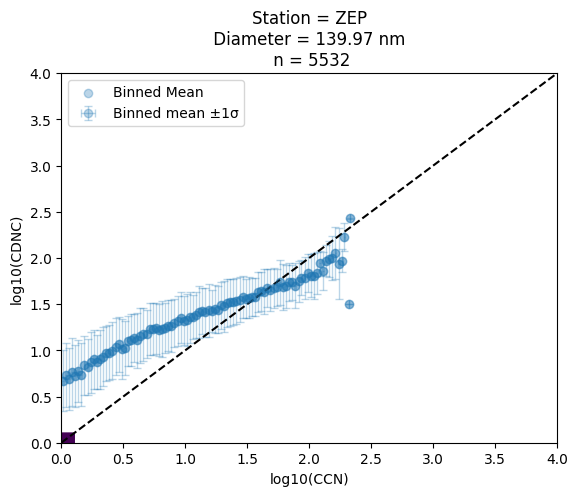

/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5290: RuntimeWarning: invalid value encountered in cast
  ix1 = np.round(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5291: RuntimeWarning: invalid value encountered in cast
  iy1 = np.round(iy).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5292: RuntimeWarning: invalid value encountered in cast
  ix2 = np.floor(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5293: RuntimeWarning: invalid value encountered in cast
  iy2 = np.floor(iy).astype(int)


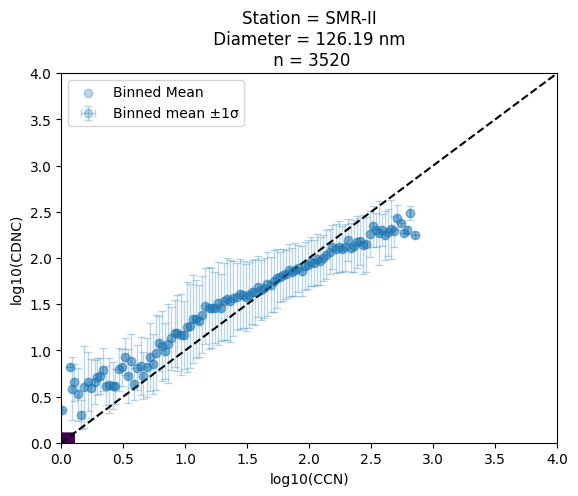

/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5290: RuntimeWarning: invalid value encountered in cast
  ix1 = np.round(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5291: RuntimeWarning: invalid value encountered in cast
  iy1 = np.round(iy).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5292: RuntimeWarning: invalid value encountered in cast
  ix2 = np.floor(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5293: RuntimeWarning: invalid value encountered in cast
  iy2 = np.floor(iy).astype(int)


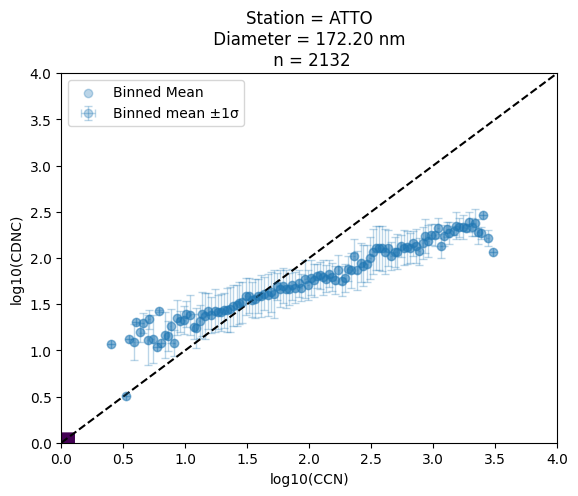

/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5290: RuntimeWarning: invalid value encountered in cast
  ix1 = np.round(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5291: RuntimeWarning: invalid value encountered in cast
  iy1 = np.round(iy).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5292: RuntimeWarning: invalid value encountered in cast
  ix2 = np.floor(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5293: RuntimeWarning: invalid value encountered in cast
  iy2 = np.floor(iy).astype(int)


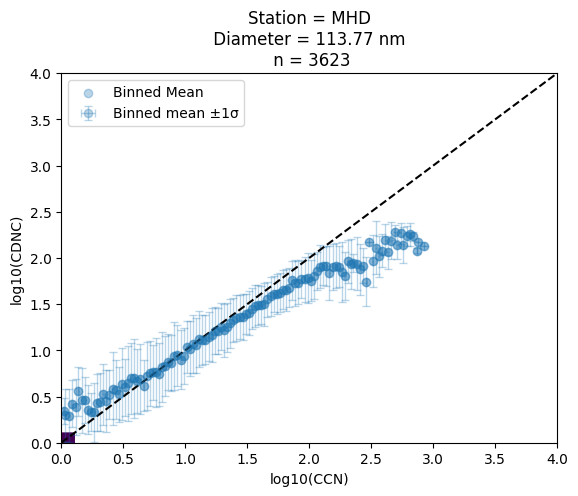

/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5290: RuntimeWarning: invalid value encountered in cast
  ix1 = np.round(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5291: RuntimeWarning: invalid value encountered in cast
  iy1 = np.round(iy).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5292: RuntimeWarning: invalid value encountered in cast
  ix2 = np.floor(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5293: RuntimeWarning: invalid value encountered in cast
  iy2 = np.floor(iy).astype(int)


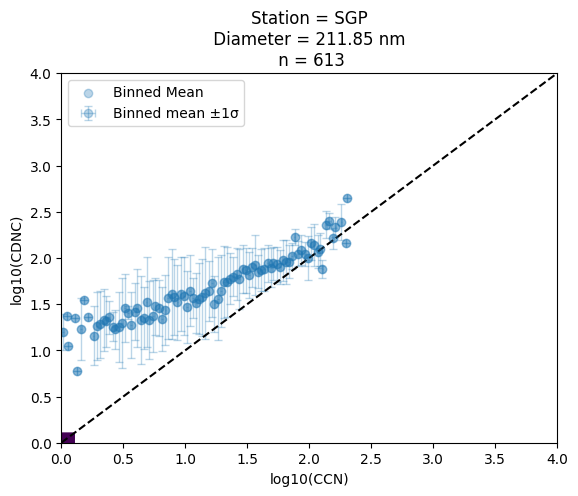

/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5290: RuntimeWarning: invalid value encountered in cast
  ix1 = np.round(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5291: RuntimeWarning: invalid value encountered in cast
  iy1 = np.round(iy).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5292: RuntimeWarning: invalid value encountered in cast
  ix2 = np.floor(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5293: RuntimeWarning: invalid value encountered in cast
  iy2 = np.floor(iy).astype(int)


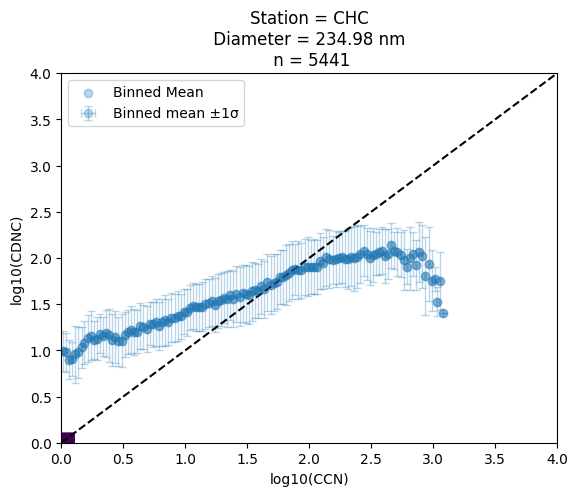

/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5290: RuntimeWarning: invalid value encountered in cast
  ix1 = np.round(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5291: RuntimeWarning: invalid value encountered in cast
  iy1 = np.round(iy).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5292: RuntimeWarning: invalid value encountered in cast
  ix2 = np.floor(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5293: RuntimeWarning: invalid value encountered in cast
  iy2 = np.floor(iy).astype(int)


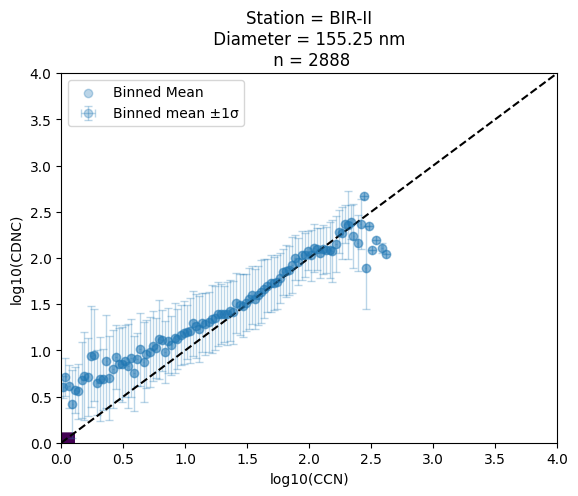

/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5290: RuntimeWarning: invalid value encountered in cast
  ix1 = np.round(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5291: RuntimeWarning: invalid value encountered in cast
  iy1 = np.round(iy).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5292: RuntimeWarning: invalid value encountered in cast
  ix2 = np.floor(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5293: RuntimeWarning: invalid value encountered in cast
  iy2 = np.floor(iy).astype(int)


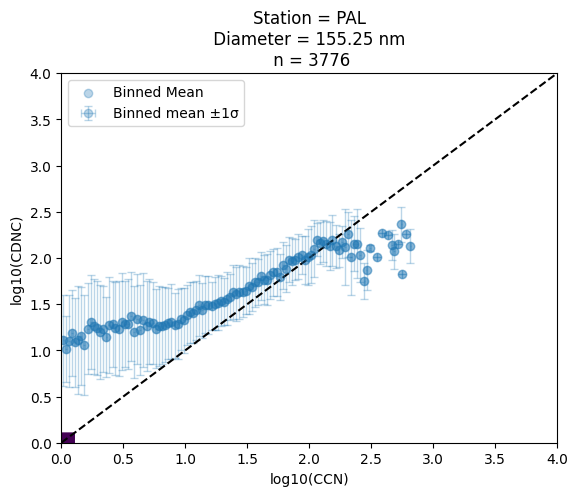

/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5290: RuntimeWarning: invalid value encountered in cast
  ix1 = np.round(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5291: RuntimeWarning: invalid value encountered in cast
  iy1 = np.round(iy).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5292: RuntimeWarning: invalid value encountered in cast
  ix2 = np.floor(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5293: RuntimeWarning: invalid value encountered in cast
  iy2 = np.floor(iy).astype(int)


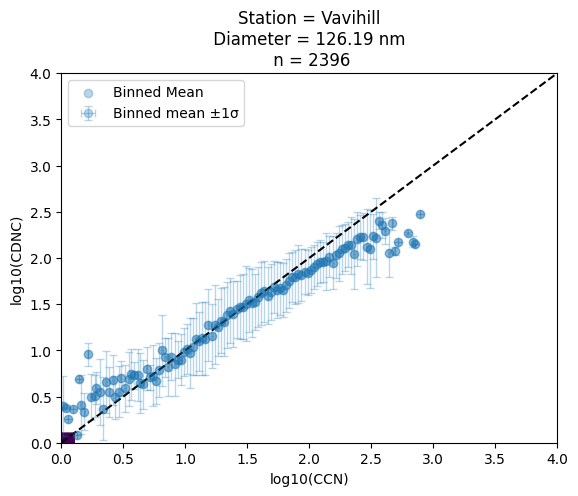

/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5290: RuntimeWarning: invalid value encountered in cast
  ix1 = np.round(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5291: RuntimeWarning: invalid value encountered in cast
  iy1 = np.round(iy).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5292: RuntimeWarning: invalid value encountered in cast
  ix2 = np.floor(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5293: RuntimeWarning: invalid value encountered in cast
  iy2 = np.floor(iy).astype(int)


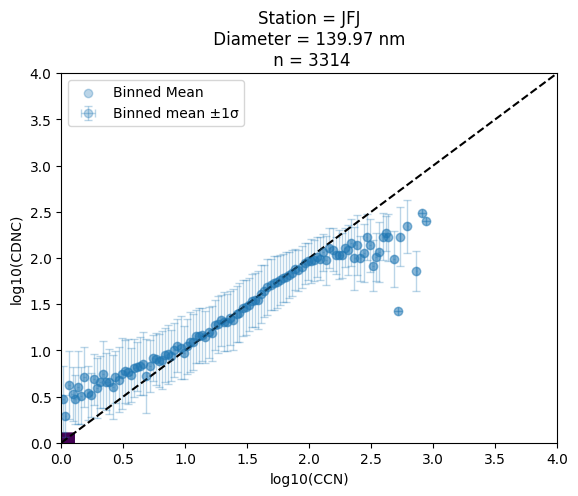

/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5290: RuntimeWarning: invalid value encountered in cast
  ix1 = np.round(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5291: RuntimeWarning: invalid value encountered in cast
  iy1 = np.round(iy).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5292: RuntimeWarning: invalid value encountered in cast
  ix2 = np.floor(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5293: RuntimeWarning: invalid value encountered in cast
  iy2 = np.floor(iy).astype(int)


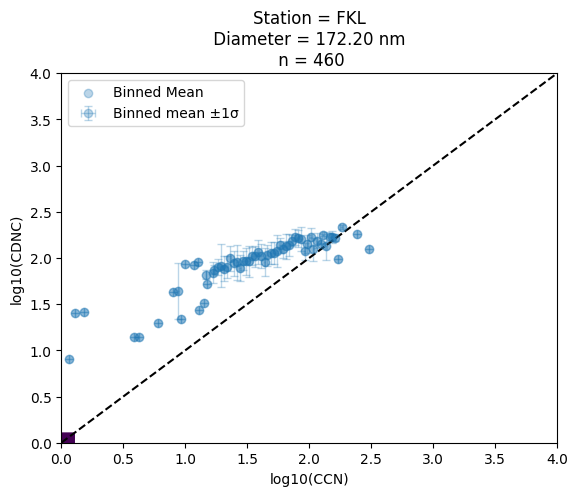

/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5290: RuntimeWarning: invalid value encountered in cast
  ix1 = np.round(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5291: RuntimeWarning: invalid value encountered in cast
  iy1 = np.round(iy).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5292: RuntimeWarning: invalid value encountered in cast
  ix2 = np.floor(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5293: RuntimeWarning: invalid value encountered in cast
  iy2 = np.floor(iy).astype(int)


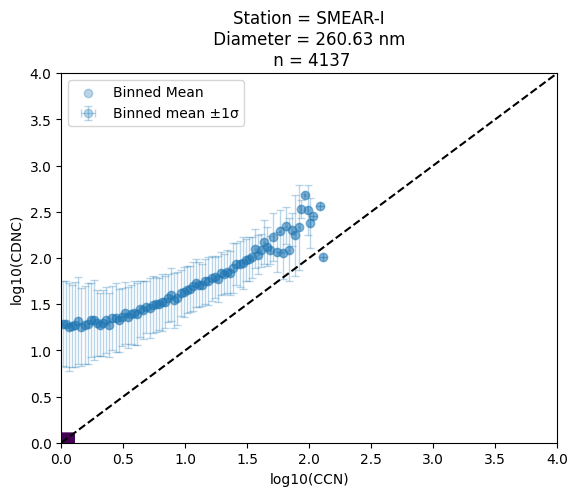

/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5290: RuntimeWarning: invalid value encountered in cast
  ix1 = np.round(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5291: RuntimeWarning: invalid value encountered in cast
  iy1 = np.round(iy).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5292: RuntimeWarning: invalid value encountered in cast
  ix2 = np.floor(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5293: RuntimeWarning: invalid value encountered in cast
  iy2 = np.floor(iy).astype(int)


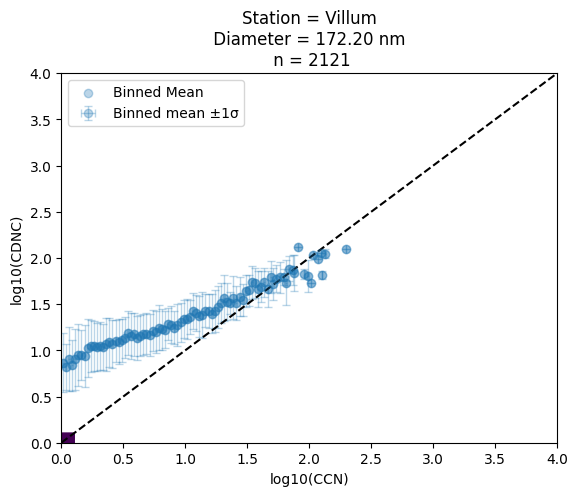

/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5290: RuntimeWarning: invalid value encountered in cast
  ix1 = np.round(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5291: RuntimeWarning: invalid value encountered in cast
  iy1 = np.round(iy).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5292: RuntimeWarning: invalid value encountered in cast
  ix2 = np.floor(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5293: RuntimeWarning: invalid value encountered in cast
  iy2 = np.floor(iy).astype(int)


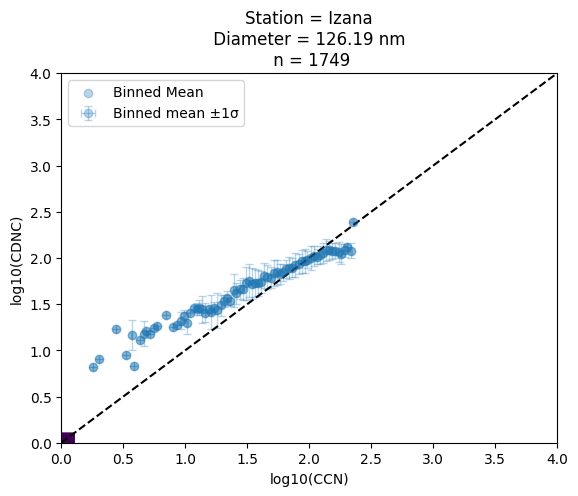

/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5290: RuntimeWarning: invalid value encountered in cast
  ix1 = np.round(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5291: RuntimeWarning: invalid value encountered in cast
  iy1 = np.round(iy).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5292: RuntimeWarning: invalid value encountered in cast
  ix2 = np.floor(ix).astype(int)
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:5293: RuntimeWarning: invalid value encountered in cast
  iy2 = np.floor(iy).astype(int)


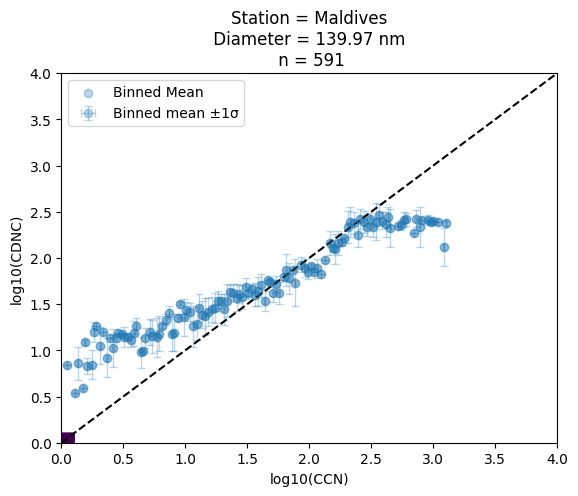

In [ ]:
reg_ds_summed['r_value'].sel(station = 'SMR-II').argmax().values

In [ ]:
reg_ds_summed['radius'].isel(radius = reg_ds_summed['r_value'].sel(station = 'SMR-II').argmax().values).values

In [ ]:
ds.WSUB.isel(lev = slice(-1,-6,-1)).mean('time').plot()

In [ ]:
for station in ['Vavihill','SMR-II','MHD', 'FKL', 'PAL']:
    print(f'{station}')
    ccn01 = np.max(ds['CCN3'].sel(station=station).mean('time', skipna=True).dropna('lev').values)
    level01 = ds['CCN3'].sel(station=station).mean('time', skipna=True).dropna('lev').argmax().values
    ccn02 = np.max(ds['CCN5'].sel(station=station).mean('time', skipna=True).dropna('lev').values)
    level02 = ds['CCN5'].sel(station=station).mean('time', skipna=True).dropna('lev').argmax().values
    ccn05 = np.max(ds['CCN6'].sel(station=station).mean('time', skipna=True).dropna('lev').values)
    level05 = ds['CCN6'].sel(station=station).mean('time', skipna=True).dropna('lev').argmax().values
    ccn1 =np.max(ds['CCN7'].sel(station=station).mean('time', skipna=True).dropna('lev').values)
    level1 = ds['CCN7'].sel(station=station).mean('time', skipna=True).dropna('lev').argmax().values

    print(f'CCN 0.1% SS = {ccn01:.2f} at level = {level01}')
    print(f'CCN 0.2% SS = {ccn02:.2f} at level = {level02}')
    print(f'CCN 0.5% SS = {ccn05:.2f} at level = {level05}')
    print(f'CCN 1.0% SS = {ccn1:.2f} at level = {level1}')
    

In [ ]:
Vavihill_CCN = [362,745,1285,1795]
SMR_CCN = [274,407,824,1128]
MHD_CCN = [472,526,691,1007]
FKL_CCNA = [946,1257,1882,2109]
FKL_CCNB = [903,1167,1793,2354]
PAL_CCNA = [7,19,50,98]
PAL_CCNB = [np.nan, np.nan, 176,247]
PAL_CCNC = [14,38,74,141]
JFJ_CCN = [135, 249, 444, 599]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

stations = ['Vavihill', 'SMR-II', 'MHD', 'FKL', 'PAL', 'JFJ']
ss_data = ['CCN3', 'CCN5', 'CCN6', 'CCN7']   # 0.1, 0.2, 0.5, 1 %
ss_labels = ['0.1%', '0.2%', '0.5%', '1%']

fig, axes = plt.subplots(len(stations), 4, figsize=(16, 14), sharex=True, sharey=True)

for i, station in enumerate(stations):          # rows
    for j, (var, ss_label) in enumerate(zip(ss_data, ss_labels)):  # columns
        
        ax = axes[i, j]
        
        CCN = ds[var].sel(station=station).isel(lev=-1).dropna('time')
        
        bins = np.logspace(
            -1,
            4,
            45
        )
        
        ax.hist(CCN, bins=bins, alpha=0.8)
        ax.set_xscale('log')
        
        # Add observation lines
        if station == 'SMR-II':
            ax.axvline(SMR_CCN[j], color='red', linestyle='--',
                       label='Obs')
        if station == 'Vavihill':
            ax.axvline(Vavihill_CCN[j], color='red', linestyle='--',
                       label='Obs')
        if station == 'MHD':
            ax.axvline(MHD_CCN[j], color='red', linestyle='--',
                       label='Obs')
        if station == 'PAL':
            ax.axvline(PAL_CCNA[j], color='red', linestyle='--',
                       label='Obs')
            ax.axvline(PAL_CCNB[j], color='red', linestyle='--',
                       label='Obs')
            ax.axvline(PAL_CCNC[j], color='red', linestyle='--',
                       label='Obs')
        if station == 'FKL':
            ax.axvline(FKL_CCNA[j], color='red', linestyle='--',
                       label='Obs')
            ax.axvline(FKL_CCNB[j], color='red', linestyle='--',
                       label='Obs')
        if station == 'JFJ':
            ax.axvline(JFJ_CCN[j], color='red', linestyle='--',
                       label='Obs')
        # Column titles (top row only)
        if i == 0:
            ax.set_title(f'{ss_label} SS')
        
        # Row labels (first column only)
        if j == 0:
            ax.set_ylabel(f'{station}\nFrequency')
        
        if i == 4:
            ax.set_xlabel('CCN ($cm^{-3}$)')

# Add legend once
axes[0,0].legend()

plt.tight_layout()
plt.show()


In [ ]:
Updraft = ds['WSUB'].isel(lev=-1)
Updraft = Updraft.dropna(dim='time')
inertias = []

for i in range(1,15):
    kmeans = KMeans(n_clusters=i, random_state = 2, init= 'k-means++')
    kmeans.fit(Updraft)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,15), inertias, marker='o')
plt.title('NorESM updraft: K-means Elbow Graph')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state = 2, init= 'k-means++')
kmeans.fit(Updraft)
KmeansUpdraft = Updraft.to_dataset()
KmeansUpdraft['label'] = xr.DataArray(kmeans.labels_, dims=('station'))
KmeansUpdraft

In [ ]:
Group1 = KmeansUpdraft.station.where(KmeansUpdraft.label == 0)
Group2 = KmeansUpdraft.station.where(KmeansUpdraft.label == 1)
Group3 = KmeansUpdraft.station.where(KmeansUpdraft.label == 2)
Group4 = KmeansUpdraft.station.where(KmeansUpdraft.label == 3)
Group5 = KmeansUpdraft.station.where(KmeansUpdraft.label == 4)
Groups = [Group1,Group2,Group3,Group4,Group5]

In [ ]:
print(f'Group 1: {Group1.dropna('station').values}')
print(f'Group 2: {Group2.dropna('station').values}')
print(f'Group 3: {Group3.dropna('station').values}')
print(f'Group 4: {Group4.dropna('station').values}')
print(f'Group 5: {Group5.dropna('station').values}')


In [ ]:
import pandas as pd

n = len(Groups)  # number of KMeans clusters

fig, axes = plt.subplots(
    1, n,
    figsize=(3*n, 3),
    sharex=True,
    sharey=True
)

# If only one cluster, axes is not iterable
if n == 1:
    axes = [axes]

for i, group in enumerate(Groups):
    
    stations = group.values
    stations = stations[~pd.isna(stations)]
    ax = axes[i]

    # Correct xarray selection
    slope = reg_ds_summed['slope'].sel(station=stations).mean('station')
    slope2 = reg_ds['slope'].sel(station=stations).mean('station')

    std_err = reg_ds_summed['std_err'].sel(station=stations).mean('station')
    std_err2 = reg_ds['std_err'].sel(station=stations).mean('station')

    # --- Column susceptibility ---
    ax.plot(radii * 2, slope, label='Column')
    ax.fill_between(
        radii * 2,
        slope - 1.96 * std_err,
        slope + 1.96 * std_err,
        alpha=0.3
    )

    # --- All-level susceptibility ---
    ax.plot(radii * 2, slope2, label='All Levels')
    ax.fill_between(
        radii * 2,
        slope2 - 1.96 * std_err2,
        slope2 + 1.96 * std_err2,
        alpha=0.3
    )

    ax.set_title(f'Cluster {i+1} \n ({stations})')
    ax.set_xscale('log')
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0.2, 1])

    # Labels
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')
axes[0].set_ylabel('Susceptibility')

# Single legend at top
axes[0].legend(frameon=False)

plt.tight_layout()
plt.show()


In [ ]:
reg_ds

In [ ]:
inertias = []

for i in range(1,15):
    kmeans = KMeans(n_clusters=i, random_state = 2, init= 'k-means++')
    kmeans.fit(reg_ds.slope.dropna('radius'))
    inertias.append(kmeans.inertia_)

plt.plot(range(1,15), inertias, marker='o')
plt.title('NorESM updraft: K-means Elbow Graph')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
Updraft

In [ ]:
kmeans = KMeans(n_clusters=5, random_state = 2, init= 'k-means++')
kmeans.fit(reg_ds.slope.dropna('radius'))
KmeansSusceptibility= reg_ds.slope.dropna('radius').to_dataset()
KmeansSusceptibility['label'] = xr.DataArray(kmeans.labels_, dims=('station'))


In [ ]:
KmeansSusceptibility.label.sel(station = 'SMR-II').values

In [ ]:
SusGroup1 = KmeansSusceptibility.station.where(KmeansSusceptibility.label == 0)
SusGroup2 = KmeansSusceptibility.station.where(KmeansSusceptibility.label == 1)
SusGroup3 = KmeansSusceptibility.station.where(KmeansSusceptibility.label == 2)
SusGroup4 = KmeansSusceptibility.station.where(KmeansSusceptibility.label == 3)
SusGroup5 = KmeansSusceptibility.station.where(KmeansSusceptibility.label == 4)
SusGroups = [SusGroup1,SusGroup2,SusGroup3,SusGroup4,SusGroup5, ]
print(f'Group 1: {SusGroup1.dropna('station').values}')
print(f'Group 2: {SusGroup2.dropna('station').values}')
print(f'Group 3: {SusGroup3.dropna('station').values}')
print(f'Group 4: {SusGroup4.dropna('station').values}')
print(f'Group 5: {SusGroup5.dropna('station').values}')
n = len(SusGroups)  # number of KMeans clusters

fig, axes = plt.subplots(
    1, n,
    figsize=(3*n, 3),
    sharex=True,
    sharey=True
)

# If only one cluster, axes is not iterable
if n == 1:
    axes = [axes]

for i, group in enumerate(SusGroups):
    
    stations = group.values
    stations = stations[~pd.isna(stations)]
    ax = axes[i]

    # Correct xarray selection
    slope = reg_ds_summed['slope'].sel(station=stations).mean('station')
    slope2 = reg_ds['slope'].sel(station=stations).mean('station')

    std_err = reg_ds_summed['std_err'].sel(station=stations).mean('station')
    std_err2 = reg_ds['std_err'].sel(station=stations).mean('station')

    # --- Column susceptibility ---
    ax.plot(radii * 2, slope, label='Column')
    ax.fill_between(
        radii * 2,
        slope - 1.96 * std_err,
        slope + 1.96 * std_err,
        alpha=0.3
    )

    # --- All-level susceptibility ---
    ax.plot(radii * 2, slope2, label='All Levels')
    ax.fill_between(
        radii * 2,
        slope2 - 1.96 * std_err2,
        slope2 + 1.96 * std_err2,
        alpha=0.3
    )

    ax.set_title(f'Cluster {i+1} \n ({stations})')
    ax.set_xscale('log')
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0.2, 1])

    # Labels
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')
axes[0].set_ylabel('Susceptibility')

# Single legend at top
axes[0].legend(frameon=False)

plt.tight_layout()
plt.show()


In [ ]:
ds['WP2_CLUBB']

In [ ]:
plt.figure(figsize= [12,8])
for x, station in enumerate(ds.station.values):
    if station in Group1:
        color = 'blue'
    if station in Group2:
        color = 'red'
    if station in Group3:
        color = 'green'
    if station in Group4:
        color = 'yellow'
    if station in Group5:
        color = 'purple'
    bins = np.linspace(0.2, ds['WP2_CLUBB'].sel(station = station).isel(ilev = -1).max().values,15)
    plt.subplot(4,4,x+1)
    plt.hist(ds['WP2_CLUBB'].sel(station = station).isel(ilev = -1),bins = bins, label = station, color=color)
    plt.legend()
plt.tight_layout()

In [ ]:
ds['WSUB'].sel(station = station).isel(lev = -1).max().values

In [ ]:
ds.time

In [ ]:
ds['WSUB']

In [ ]:

cluster_counts = np.zeros((n_stations, n_stations))
for cluster_number in range(2,6):
    kmeans = KMeans(n_clusters=cluster_number, random_state = 2, init= 'k-means++')
    kmeans.fit(Updraft)
    KmeansUpdraft = Updraft.to_dataset()
    KmeansUpdraft['label'] = xr.DataArray(kmeans.labels_, dims=('station'))
    for x in range(len(ds.station.values)):
        for y in range(x+1,len(ds.station.values)):
            if x == y:
                continue
            if KmeansUpdraft.label.isel(station = x).values == KmeansUpdraft.label.isel(station = y).values:
                cluster_counts[x,y] = cluster_counts[x,y] +1
            else:
                continue
        

In [ ]:
cluster_counts

In [ ]:
ds.station.values[0]

In [ ]:
for cluster_number in range(2,15):
    print(cluster_number)


In [ ]:
from pycirclize import Circos
import pandas as pd

# Create matrix data (10 x 10)
row_names = ds.station.values
col_names = ds.station.values
matrix_data = cluster_counts
matrix_df = pd.DataFrame(matrix_data, index=row_names, columns=col_names)

# Initialize from matrix (Can also directly load tsv matrix file)
circos = Circos.initialize_from_matrix(
    matrix_df,
    space=3,
    r_lim=(93, 100),
    ticks_interval=500,
    label_kws=dict(r=94, size=12, color="white"),
)


In [ ]:
circos.plotfig()

In [ ]:
for x in range(len(ds.station.values)):
    print(x)


In [ ]:
AitAcc_ds = Function.NorERF(ds,[20,100])
N100 = AitAcc_ds.sel(radius = 100) 
N20 = AitAcc_ds.sel(radius = 20) -AitAcc_ds.sel(radius = 100) 
AitAccRatio = N20/N100

In [ ]:
mask = (AitAccRatio <= 10).compute().reset_coords("radius", drop=True)
BigAcc = CCN_all.where(mask, drop=True)

mask = (AitAccRatio >= 100).compute().reset_coords("radius", drop=True)
BigAit = CCN_all.where(mask, drop=True)



In [ ]:
BigAcc = BigAcc.where(BigAcc.CDNC.notnull(), drop = True)
BigAit = BigAit.where(BigAit.CDNC.notnull(), drop = True)


In [ ]:
CDNC_b, CCN_b = xr.broadcast(BigAcc.CDNC, BigAcc.CCN)
Pairs_acc = xr.Dataset({
    "CDNC": CDNC_b,
    "CCN": CCN_b
}).stack(sample=("station", "time", "lev"))
Pairs_acc = Pairs_acc.where(Pairs_acc.CDNC.notnull(), drop=True)
Pairs_acc['CDNC'] = Pairs_acc['CDNC'].isel(radius = 0)

In [ ]:
CDNC_b, CCN_b = xr.broadcast(BigAit.CDNC, BigAit.CCN)
Pairs_ait = xr.Dataset({
    "CDNC": CDNC_b,
    "CCN": CCN_b
}).stack(sample=("station", "time", "lev"))
Pairs_ait = Pairs_ait.where(Pairs_ait.CDNC.notnull(), drop=True)
Pairs_ait['CDNC'] = Pairs_ait['CDNC'].isel(radius = 0)

In [ ]:
Pairs_acc.isel(radius = 58)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Count occurrences of each station
station_counts = pd.Series(Pairs_acc.station.values).value_counts()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(station_counts.index, station_counts.values, color='steelblue', edgecolor='white')

# Add count labels on top of each bar
for bar, count in zip(bars, station_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            str(count), ha='center', va='bottom', fontsize=9)

ax.set_title('High Accumulation Mode instances per Station', fontsize=14, fontweight='bold')
ax.set_xlabel('Station', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Count occurrences of each station
station_counts = pd.Series(Pairs_ait.station.values).value_counts()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(station_counts.index, station_counts.values, color='steelblue', edgecolor='white')

# Add count labels on top of each bar
for bar, count in zip(bars, station_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            str(count), ha='center', va='bottom', fontsize=9)

ax.set_title('High Aitken Mode instances per Station', fontsize=14, fontweight='bold')
ax.set_xlabel('Station', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
def segments_fit(X, Y, maxcount):
    xmin = X.min()
    xmax = X.max()
    
    n = len(X)
    
    AIC_ = float('inf')
    BIC_ = float('inf')
    r_   = None
    
    for count in range(1, maxcount+1):
        
        seg = np.full(count - 1, (xmax - xmin) / count)

        px_init = np.r_[np.r_[xmin, seg].cumsum(), xmax]
        py_init = np.array([Y[np.abs(X - x) < (xmax - xmin) * 0.1].mean() for x in px_init])

        def func(p):
            seg = p[:count - 1]
            py = p[count - 1:]
            px = np.r_[np.r_[xmin, seg].cumsum(), xmax]
            return px, py

        def err(p): # This is RSS / n
            px, py = func(p)
            Y2 = np.interp(X, px, py)
            return np.mean((Y - Y2)**2)

        r = optimize.minimize(err, x0=np.r_[seg, py_init], method='Nelder-Mead')
    
        # Compute AIC/ BIC. 
        AIC = n * np.log10(err(r.x)) + 4 * count
        BIC = n * np.log10(err(r.x)) + 2 * count * np.log(n)
        
        if((BIC < BIC_) & (AIC < AIC_)): # Continue adding complexity.
            r_ = r
            AIC_ = AIC
            BIC_ = BIC
        else: # Stop.
            count = count - 1
            break
        
    return func(r_.x) ## Return the last (n-1)

In [ ]:
bins = np.logspace(0, 4, 101)  # 10^0=1, 10^4=10000'
BigAitReg_ds = xr.Dataset(
    data_vars={
        "slope":     ("radius", np.full(len(radii), np.nan)),
        "r_value":   ("radius", np.full(len(radii), np.nan)),
        "std_err":   ("radius", np.full(len(radii), np.nan)),
        "intercept": ("radius", np.full(len(radii), np.nan)),
    },
    coords={"radius": radii}
)
for r in range(len(radii)):

    CCN_slice = Pairs_ait.CCN.isel(radius=r)
    valid = CCN_slice.where(CCN_slice > 1).dropna("sample")
    if len(valid) < 2:
        continue
    # Bin by CCN
    CCN_binned = CCN_slice.groupby_bins(CCN_slice, bins).mean()
    CDNC_binned = Pairs_ait.CDNC.groupby_bins(CCN_slice, bins).mean()

    x = np.log10(CCN_binned.values)
    y = np.log10(CDNC_binned.values)

    mask = np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 20:
        continue  # avoid linregress crash

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        x[mask], y[mask]
    )

    # Assign into Dataset
    BigAitReg_ds["slope"].loc[{"radius": radii[r]}]     = slope
    BigAitReg_ds["r_value"].loc[{"radius": radii[r]}]   = r_value
    BigAitReg_ds["std_err"].loc[{"radius": radii[r]}]   = std_err
    BigAitReg_ds["intercept"].loc[{"radius": radii[r]}] = intercept

In [ ]:
BigAccReg_ds = xr.Dataset(
    data_vars={
        "slope":     ("radius", np.full(len(radii), np.nan)),
        "r_value":   ("radius", np.full(len(radii), np.nan)),
        "std_err":   ("radius", np.full(len(radii), np.nan)),
        "intercept": ("radius", np.full(len(radii), np.nan)),
        "slope1": ("radius", np.full(len(radii), np.nan)),
        "slope2": ("radius", np.full(len(radii), np.nan)),
        "breakpoint": ("radius", np.full(len(radii), np.nan)),
        "px": (["radius", "segment"], np.full((len(radii), 3), np.nan)),  # 2D
        "py": (["radius", "segment"], np.full((len(radii), 3), np.nan)),  # 2D
    },
    coords={
        "radius": radii,
        "segment": [0, 1, 2]
    }
)
for r in range(len(radii)):
    CCN_slice = Pairs_acc.CCN.isel(radius = r)

    # Bin by CCN
    CCN_binned = CCN_slice.groupby_bins(CCN_slice, bins).mean()
    CDNC_binned = Pairs_acc.CDNC.groupby_bins(CCN_slice, bins).mean()

    x = np.log10(CCN_binned.values)
    y = np.log10(CDNC_binned.values)

    mask = np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 4:
        continue  # avoid linregress crash

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        x[mask], y[mask]
    )
    
    px, py = segments_fit(x[mask], y[mask], 2)

    if len(px) == 3:  # 2 segments found
        slope1 = (py[1] - py[0]) / (px[1] - px[0])
        slope2 = (py[2] - py[1]) / (px[2] - px[1])
        breakpoint_val = 10**px[1]
    else:  
        slope1 = np.nan  
        slope2 = np.nan
        breakpoint_val = np.nan


    # Assign into Dataset
    BigAccReg_ds["slope"].loc[{"radius": radii[r]}]     = slope
    BigAccReg_ds["r_value"].loc[{"radius": radii[r]}]   = r_value
    BigAccReg_ds["std_err"].loc[{"radius": radii[r]}]   = std_err
    BigAccReg_ds["intercept"].loc[{"radius": radii[r]}] = intercept
    BigAccReg_ds["slope1"].loc[{"radius": radii[r]}]     = slope1
    BigAccReg_ds["slope2"].loc[{"radius": radii[r]}]     = slope2
    BigAccReg_ds["breakpoint"].loc[{"radius": radii[r]}] = breakpoint_val
    if len(px) == 3:
        BigAccReg_ds["px"].loc[{"radius": radii[r]}] = px
        BigAccReg_ds["py"].loc[{"radius": radii[r]}] = py
    # if len(px) == 2, px/py stay as NaN for that radius


In [ ]:
Pairs_noCHC = Pairs_acc.where(Pairs_acc.station != 'CHC', drop=True)
BigAccReg_noCHC_ds = xr.Dataset(
    data_vars={
        "slope":     ("radius", np.full(len(radii), np.nan)),
        "r_value":   ("radius", np.full(len(radii), np.nan)),
        "std_err":   ("radius", np.full(len(radii), np.nan)),
        "intercept": ("radius", np.full(len(radii), np.nan)),
        "slope1": ("radius", np.full(len(radii), np.nan)),
        "slope2": ("radius", np.full(len(radii), np.nan)),
        "breakpoint": ("radius", np.full(len(radii), np.nan)),
        "px": (["radius", "segment"], np.full((len(radii), 3), np.nan)),  # 2D
        "py": (["radius", "segment"], np.full((len(radii), 3), np.nan)),  # 2D
    },
    coords={
        "radius": radii,
        "segment": [0, 1, 2]
    }
)
for r in range(len(radii)):
    CCN_slice = Pairs_noCHC.CCN.isel(radius = r)

    # Bin by CCN
    CCN_binned = CCN_slice.groupby_bins(CCN_slice, bins).mean()
    CDNC_binned = Pairs_noCHC.CDNC.groupby_bins(CCN_slice, bins).mean()

    x = np.log10(CCN_binned.values)
    y = np.log10(CDNC_binned.values)

    mask = np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 4:
        continue  # avoid linregress crash

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        x[mask], y[mask]
    )
    
    px, py = segments_fit(x[mask], y[mask], 2)

    if len(px) == 3:  # 2 segments found
        slope1 = (py[1] - py[0]) / (px[1] - px[0])
        slope2 = (py[2] - py[1]) / (px[2] - px[1])
        breakpoint_val = 10**px[1]
    else:  
        slope1 = np.nan  
        slope2 = np.nan
        breakpoint_val = np.nan


    # Assign into Dataset
    BigAccReg_noCHC_ds["slope"].loc[{"radius": radii[r]}]     = slope
    BigAccReg_noCHC_ds["r_value"].loc[{"radius": radii[r]}]   = r_value
    BigAccReg_noCHC_ds["std_err"].loc[{"radius": radii[r]}]   = std_err
    BigAccReg_noCHC_ds["intercept"].loc[{"radius": radii[r]}] = intercept
    BigAccReg_noCHC_ds["slope1"].loc[{"radius": radii[r]}]     = slope1
    BigAccReg_noCHC_ds["slope2"].loc[{"radius": radii[r]}]     = slope2
    BigAccReg_noCHC_ds["breakpoint"].loc[{"radius": radii[r]}] = breakpoint_val
    if len(px) == 3:
        BigAccReg_noCHC_ds["px"].loc[{"radius": radii[r]}] = px
        BigAccReg_noCHC_ds["py"].loc[{"radius": radii[r]}] = py
    # if len(px) == 2, px/py stay as NaN for that radius


In [ ]:
import warnings
import numpy as np

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    
    for level in all_levels:
        for r in range(len(radii)):
            CCN_slice = Pairs_acc.CCN.sel(lev=level).isel(radius=r)

            try:
                CCN_binned  = CCN_slice.groupby_bins(CCN_slice, bins).mean()
                CDNC_binned = Pairs_acc.CDNC.sel(lev=level).groupby_bins(CCN_slice, bins).mean()
            except ValueError:
                continue

            x = np.log10(CCN_binned.values)
            y = np.log10(CDNC_binned.values)
            mask = np.isfinite(x) & np.isfinite(y)

            if mask.sum() < 4:
                continue

            slope, intercept, r_value, p_value, std_err = stats.linregress(x[mask], y[mask])
            px, py = segments_fit(x[mask], y[mask], 2)

            if len(px) == 3:
                slope1         = (py[1] - py[0]) / (px[1] - px[0])
                slope2         = (py[2] - py[1]) / (px[2] - px[1])
                breakpoint_val = 10**px[1]
            else:
                slope1 = slope2 = breakpoint_val = np.nan

            loc = {"radius": radii[r], "lev": level}
            BigAccReg_lev_ds["slope"].loc[loc]      = slope
            BigAccReg_lev_ds["r_value"].loc[loc]    = r_value
            BigAccReg_lev_ds["std_err"].loc[loc]    = std_err
            BigAccReg_lev_ds["intercept"].loc[loc]  = intercept
            BigAccReg_lev_ds["slope1"].loc[loc]     = slope1
            BigAccReg_lev_ds["slope2"].loc[loc]     = slope2
            BigAccReg_lev_ds["breakpoint"].loc[loc] = breakpoint_val
            if len(px) == 3:
                BigAccReg_lev_ds["px"].loc[loc] = px
                BigAccReg_lev_ds["py"].loc[loc] = py

In [ ]:
BigAccReg_ds.isel(radius = (BigAccReg_ds.slope1 - BigAccReg_ds.slope).argmax())

In [ ]:
BigAitReg_ds

In [ ]:
Pairs_acc.station.where(Pairs_acc['CCN'].isel(radius = 40) < BigAccReg_ds['breakpoint'].isel(radius = 40).values, drop = True).values

In [ ]:
BigAccReg_lev_ds.lev.values

In [ ]:
inertias = []

for i in range(1,15):
    kmeans = KMeans(n_clusters=i, random_state = 3, init= 'k-means++')
    kmeans.fit(AitAccRatio.isel(lev = -1).dropna('time'))
    inertias.append(kmeans.inertia_)

plt.plot(range(1,15), inertias, marker='o')
plt.title('NorESM updraft: K-means Elbow Graph')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state = 2, init= 'k-means++')
kmeans.fit(AitAccRatio.isel(lev = -1).dropna('time'))
KmeansAitAcc= AitAccRatio.isel(lev = -1).dropna('time').to_dataset()
KmeansAitAcc['label'] = xr.DataArray(kmeans.labels_, dims=('station'))

In [ ]:
AitAccGroup1 = KmeansAitAcc.station.where(KmeansAitAcc.label == 0)
AitAccGroup2 = KmeansAitAcc.station.where(KmeansAitAcc.label == 1)
AitAccGroup3 = KmeansAitAcc.station.where(KmeansAitAcc.label == 2)
AitAccGroup4 = KmeansAitAcc.station.where(KmeansAitAcc.label == 3)
AitAccGroup5 = KmeansAitAcc.station.where(KmeansAitAcc.label == 4)
AitAccGroups = [AitAccGroup1,AitAccGroup2,AitAccGroup3,AitAccGroup4,AitAccGroup5, ]
print(f'Group 1: {AitAccGroup1.dropna('station').values}')
print(f'Group 2: {AitAccGroup2.dropna('station').values}')
print(f'Group 3: {AitAccGroup3.dropna('station').values}')
print(f'Group 4: {AitAccGroup4.dropna('station').values}')
print(f'Group 5: {AitAccGroup5.dropna('station').values}')

In [ ]:
stations = reg_ds.station.values

slope = reg_ds_lev['slope'].sel(radius = 35, method='nearest')
plt.scatter(slope, height)
    
plt.title('NorESM Susceptibiltiy with Height', fontsize=10)
plt.xlim([0,1])
plt.ylim([0, 7500])
plt.ylabel('Height (m)')
plt.xlabel('Susceptibility')

plt.show()

In [ ]:
bins = np.linspace(0.2, 2, 25)

plt.figure(figsize= [12,8])
for x, station in enumerate(ds.station.values):
    if station in Group1:
        color = 'blue'
    if station in Group2:
        color = 'red'
    if station in Group3:
        color = 'green'
    if station in Group4:
        color = 'yellow'
    if station in Group5:
        color = 'purple'
    plt.subplot(4,4,x+1)
    plt.hist(ds['WSUB'].sel(station = station).isel(lev = -1),bins = bins, label = station, color=color)
    plt.legend()
plt.tight_layout()

In [ ]:
bins = np.logspace(0,3, 25)
plt.figure(figsize= [12,8])
for x, station in enumerate(ds.station.values):
    if station in AitAccGroup1:
        color = 'blue'
    if station in AitAccGroup2:
        color = 'red'
    if station in AitAccGroup3:
        color = 'green'
    if station in AitAccGroup4:
        color = 'yellow'
    if station in AitAccGroup5:
        color = 'purple'
    plt.subplot(4,4,x+1)
    plt.hist(AitAccRatio.sel(station = station).isel(lev = -1), bins = bins, label = station, color='steel blue')
    plt.xscale('log')
    plt.legend()
plt.tight_layout()

In [ ]:
import numpy as np

# Ensure correct dimension order
Updraft = ds['WSUB'].isel(lev = -1).transpose('station', 'time')

# Convert to NumPy
X = Updraft.values   # shape: (15, 8761)

In [ ]:
# Ensure correct dimension order
Sus = reg_ds.slope.transpose('station', 'radius').dropna('radius')

# Convert to NumPy
X = Sus.values   # shape: (15, 60)

In [ ]:
plt.scatter(reg_ds.slope.sel(station = 'SMEAR-I'), reg_ds.slope.sel(station = 'SMR-II') )

In [ ]:
AitAcc = AitAccRatio.isel(lev = -1).transpose('station', 'time')
# Convert to NumPy
#X = AitAcc.values   # shape: (15, T)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Correlation matrix between stations
corr_matrix = np.corrcoef(X)

# Convert to distance matrix
distance_matrix = 1 - corr_matrix

In [ ]:
condensed_dist

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

# Convert square matrix to condensed form
condensed_dist = squareform(distance_matrix, checks=False)

# Perform clustering (average linkage recommended)
Z = linkage(condensed_dist, method='average')

In [ ]:
plt.figure(figsize = [15,5])
dendrogram(
    Z,
    labels=Updraft.station.values,
    color_threshold=0.5
)
plt.title("Hierarchical Clustering (Correlation Distance)")
plt.xlabel("Station")
plt.ylabel("1 - Correlation")
plt.show()

In [ ]:
from scipy.cluster.hierarchy import fcluster

k = 5   # choose desired number
labels = fcluster(Z, k, criterion='maxclust')

In [ ]:
Updraft_clustered = Updraft.to_dataset(name="Updraft")
Updraft_clustered["cluster"] = (
    "station",
    labels
)

In [ ]:
bins = np.linspace(0.2, 2, 25)

plt.figure(figsize= [12,8])
for x, station in enumerate(ds.station.values):
    if Updraft_clustered.sel(station = station).cluster.values == 1:
        color = 'blue'
    if Updraft_clustered.sel(station = station).cluster.values == 2:
        color = 'red'
    if Updraft_clustered.sel(station = station).cluster.values == 3:
        color = 'green'
    if Updraft_clustered.sel(station = station).cluster.values == 4:
        color = 'yellow'
    if Updraft_clustered.sel(station = station).cluster.values == 5:
        color = 'purple'
    plt.subplot(4,4,x+1)
    plt.hist(ds['WSUB'].sel(station = station).isel(lev = -1),bins = bins, label = station, color=color)
    plt.legend()
plt.tight_layout()

In [ ]:
Updraft_clustered.sel(station = station).cluster.values

In [ ]:
AitAccRatio

In [ ]:
#!pip install pwlf

In [ ]:
import pwlf
crit_D = []
crit_D_summed= []

for station in reg_ds.station.values:

    y = reg_ds.slope.sel(station=station).dropna(dim='radius')
    y2 = reg_ds_summed.slope.sel(station=station).dropna(dim='radius')
    radius = reg_ds.radius*2



    mask = y.notnull()
    mask2 = y2.notnull()
    x = np.log10(radius.where(mask))
    x2 = np.log10(radius.where(mask2))
    
    # Convert to numpy arrays
    x = x.values
    x2 = x2.values

    y = y.values
    y2 = y2.values

    # Skip if insufficient data
    if len(x) < 10:
        print(station, "Not enough data")
        continue

    # Fit piecewise linear model
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    breaks = my_pwlf.fit(2)
    my_pwlf2 = pwlf.PiecewiseLinFit(x2, y2)
    breaks2 = my_pwlf2.fit(2)

    knee_log = breaks[1]
    knee_log2 = breaks2[1]

    Crit_D = 10**knee_log
    Crit_D2 = 10**knee_log2 
    crit_D.append(Crit_D)
    crit_D_summed.append(Crit_D2)
    print(station)
    print('All:', Crit_D)
    print('Summed:', Crit_D2)

In [ ]:
import pwlf
crit_D_corr = []
crit_D_summed_corr = []

for station in reg_ds.station.values:

    y = reg_ds.r_value.sel(station=station).dropna(dim='radius')
    y2 = reg_ds_summed.r_value.sel(station=station).dropna(dim='radius')
    radius = reg_ds.radius*2



    mask = y.notnull()
    mask2 = y2.notnull()
    x = np.log10(radius.where(mask))
    x2 = np.log10(radius.where(mask2))
    
    # Convert to numpy arrays
    x = x.values
    x2 = x2.values

    y = y.values
    y2 = y2.values
    #y = savgol_filter(y, 9, 2)

    # Skip if insufficient data
    if len(x) < 10:
        print(station, "Not enough data")
        continue

    # Fit piecewise linear model
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    breaks = my_pwlf.fit(2)
    my_pwlf2 = pwlf.PiecewiseLinFit(x2, y2)
    breaks2 = my_pwlf2.fit(2)

    knee_log = breaks[1]
    knee_log2 = breaks2[1]

    Crit_D = 10**knee_log
    Crit_D2 = 10**knee_log2 
    crit_D_corr.append(Crit_D)
    crit_D_summed_corr.append(Crit_D2)
    print(station)
    print('All:', Crit_D)
    print('Summed:', Crit_D2)

In [ ]:
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

In [ ]:
stations = reg_ds_summed.station.values
n_stations = len(stations)

fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):
    
    ax = axes[i]
    # Split data
    mask1 = reg_ds['radius'] < crit_D[i]/2
    mask2 = reg_ds['radius'] >= crit_D[i]/2

    r1 = reg_ds['radius'].where(mask1, drop=True)
    r2 = reg_ds['radius'].where(mask2, drop=True)

    x1 = np.log10(r1 * 2)
    y1 = reg_ds['slope'].sel(station=station).where(mask1, drop=True)

    x2 = np.log10(r2 * 2)
    y2 = reg_ds['slope'].sel(station=station).where(mask2, drop=True)

    # First regression
    if len(x1) > 2:
        slope1, intercept1, *_ = stats.linregress(x1, y1)

        # Predict using log10(x)
        y1_fit = slope1 * np.log10(r1 * 2) + intercept1
        ax.plot(r1 * 2, y1_fit)

    # Second regression
    if len(x2) > 2:
        slope2, intercept2, *_ = stats.linregress(x2, y2)

        y2_fit = slope2 * np.log10(r2 * 2) + intercept2
        ax.plot(r2 * 2, y2_fit)
    #Repeat for the correlation split
    # Split data
    mask1 = reg_ds['radius'] < crit_D_corr[i]/2
    mask2 = reg_ds['radius'] >= crit_D_corr[i]/2

    r1 = reg_ds['radius'].where(mask1, drop=True)
    r2 = reg_ds['radius'].where(mask2, drop=True)

    x1 = np.log10(r1 * 2)
    y1 = reg_ds['slope'].sel(station=station).where(mask1, drop=True)

    x2 = np.log10(r2 * 2)
    y2 = reg_ds['slope'].sel(station=station).where(mask2, drop=True)

    # First regression
    if len(x1) > 2:
        slope1, intercept1, *_ = stats.linregress(x1, y1)

        # Predict using log10(x)
        y1_fit = slope1 * np.log10(r1 * 2) + intercept1
        ax.plot(r1 * 2, y1_fit)

    # Second regression
    if len(x2) > 2:
        slope2, intercept2, *_ = stats.linregress(x2, y2)

        y2_fit = slope2 * np.log10(r2 * 2) + intercept2
        ax.plot(r2 * 2, y2_fit)
    
        # --- First cutoff (crit_D)
    maskA = reg_ds['radius'] < crit_D[i]/2
    rA = reg_ds['radius'].where(maskA, drop=True)
    xA = np.log10(rA * 2)
    yA = reg_ds['slope'].sel(station=station).where(maskA, drop=True)
    
    # --- Second cutoff (crit_D_corr)
    maskB = reg_ds['radius'] < crit_D_corr[i]/2
    rB = reg_ds['radius'].where(maskB, drop=True)
    xB = np.log10(rB * 2)
    yB = reg_ds['slope'].sel(station=station).where(maskB, drop=True)
    
    if len(xA) > 2 and len(xB) > 2:
    
        slopeA, _, _, pA, seA = stats.linregress(xA, yA)
        slopeB, _, _, pB, seB = stats.linregress(xB, yB)
    
        # test difference
        t_stat = (slopeA - slopeB) / np.sqrt(seA**2 + seB**2)
        df = len(xA) + len(xB) - 4
        p_diff = 2 * (1 - stats.t.cdf(abs(t_stat), df))
    
        print(f"\nStation: {station}")
        print(f"Slope (crit_D) p vs 0: {pA:.4f}")
        print(f"Slope (crit_D_corr) p vs 0: {pB:.4f}")
        print(f"Slope difference p-value: {p_diff:.4f}")

    # --- First cutoff (crit_D)
    maskA = reg_ds['radius'] < crit_D[i]/2
    rA = reg_ds['radius'].where(maskA, drop=True)
    xA = np.log10(rA * 2)
    yA = reg_ds['slope'].sel(station=station).where(maskA, drop=True)
    
    # --- Second cutoff (crit_D_corr)
    maskB = reg_ds['radius'] < crit_D_corr[i]/2
    rB = reg_ds['radius'].where(maskB, drop=True)
    xB = np.log10(rB * 2)
    yB = reg_ds['slope'].sel(station=station).where(maskB, drop=True)
    
    if len(xA) > 2 and len(xB) > 2:
    
        slopeA, _, _, pA, seA = stats.linregress(xA, yA)
        slopeB, _, _, pB, seB = stats.linregress(xB, yB)
    
        # slope difference test
        t_stat = (slopeA - slopeB) / np.sqrt(seA**2 + seB**2)
        df = len(xA) + len(xB) - 4
        p_diff = 2 * (1 - stats.t.cdf(abs(t_stat), df))
    
        starsA = significance_stars(pA)
        starsB = significance_stars(pB)
        starsDiff = significance_stars(p_diff)
    
        # --- Add text annotation to subplot
        textstr = (
            f"D_crit = {crit_D[i]:.2f} nm \n"
            f"D_crit (corr) = {crit_D_corr[i]:.2f} nm \n"
            f"Dp < D_crit: {starsA}\n"
            f"Dp < D_crit (corr): {starsB}\n"
            f"Difference: {starsDiff}"
        )
    
        ax.text(
            0.05, 0.3,
            textstr,
            transform=ax.transAxes,
            fontsize=8,
            verticalalignment='top',
            bbox=dict(boxstyle='round', alpha=0.2)
        )

    slope = reg_ds['slope'].sel(station=station)
    std_err = reg_ds['std_err'].sel(station=station)
    r_val = reg_ds['r_value'].sel(station=station)


    ax.plot(radii * 2, slope, label='Susceptibility', color = 'black')
    ax.fill_between(
        radii * 2,
        slope - 1.96 * std_err,
        slope + 1.96 * std_err,
        alpha=0.3,
        label='95% Confidence Interval',
        color = 'black'
    )
    ax.plot(radii * 2, r_val, label='Correlation', color = 'black', ls = '-.')
    ax.axvline(crit_D[i], color = 'red',ls =  '--', label = 'Critical Diameter (Susceptibility)')
    
    ax.axvline(crit_D_corr[i], color = 'blue', ls = '--', label = 'Critical Diameter (Correlation)')

    ax.set_title(station, fontsize=10)
    ax.set_xscale('log')
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0.2, 1])

# --- Last panel used only for legend ---
legend_ax = axes[-1]
legend_ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(
    handles,
    labels,
    loc='center',
    frameon=False,
    fontsize=10
)

# Axis labels (only on outer edges)
for ax in axes[12:16]:
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')

for ax in axes[::4]:
    ax.set_ylabel('Susceptibility / Correlation')

plt.tight_layout()
plt.show()



In [ ]:
stations = reg_ds_summed.station.values
n_stations = len(stations)

fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):
    
    ax = axes[i]
    # Split data
    mask1 = reg_ds_summed['radius'] < crit_D_summed[i]/2
    mask2 = reg_ds_summed['radius'] >= crit_D_summed[i]/2

    r1 = reg_ds_summed['radius'].where(mask1, drop=True)
    r2 = reg_ds_summed['radius'].where(mask2, drop=True)

    x1 = np.log10(r1 * 2)
    y1 = reg_ds_summed['slope'].sel(station=station).where(mask1, drop=True)

    x2 = np.log10(r2 * 2)
    y2 = reg_ds_summed['slope'].sel(station=station).where(mask2, drop=True)

    # First regression
    if len(x1) > 2:
        slope1, intercept1, *_ = stats.linregress(x1, y1)

        # Predict using log10(x)
        y1_fit = slope1 * np.log10(r1 * 2) + intercept1
        ax.plot(r1 * 2, y1_fit)

    # Second regression
    if len(x2) > 2:
        slope2, intercept2, *_ = stats.linregress(x2, y2)

        y2_fit = slope2 * np.log10(r2 * 2) + intercept2
        ax.plot(r2 * 2, y2_fit)
    #Repeat for the correlation split
    # Split data
    mask1 = reg_ds_summed['radius'] < crit_D_summed_corr[i]/2
    mask2 = reg_ds_summed['radius'] >= crit_D_summed_corr[i]/2

    r1 = reg_ds_summed['radius'].where(mask1, drop=True)
    r2 = reg_ds_summed['radius'].where(mask2, drop=True)

    x1 = np.log10(r1 * 2)
    y1 = reg_ds_summed['slope'].sel(station=station).where(mask1, drop=True)

    x2 = np.log10(r2 * 2)
    y2 = reg_ds_summed['slope'].sel(station=station).where(mask2, drop=True)

    # First regression
    if len(x1) > 2:
        slope1, intercept1, *_ = stats.linregress(x1, y1)

        # Predict using log10(x)
        y1_fit = slope1 * np.log10(r1 * 2) + intercept1
        ax.plot(r1 * 2, y1_fit)

    # Second regression
    if len(x2) > 2:
        slope2, intercept2, *_ = stats.linregress(x2, y2)

        y2_fit = slope2 * np.log10(r2 * 2) + intercept2
        ax.plot(r2 * 2, y2_fit)
    
        # --- First cutoff (crit_D_summed)
    maskA = reg_ds_summed['radius'] < crit_D_summed[i]/2
    rA = reg_ds_summed['radius'].where(maskA, drop=True)
    xA = np.log10(rA * 2)
    yA = reg_ds_summed['slope'].sel(station=station).where(maskA, drop=True)
    
    # --- Second cutoff (crit_D_summed_corr)
    maskB = reg_ds_summed['radius'] < crit_D_summed_corr[i]/2
    rB = reg_ds_summed['radius'].where(maskB, drop=True)
    xB = np.log10(rB * 2)
    yB = reg_ds_summed['slope'].sel(station=station).where(maskB, drop=True)
    
    if len(xA) > 2 and len(xB) > 2:
    
        slopeA, _, _, pA, seA = stats.linregress(xA, yA)
        slopeB, _, _, pB, seB = stats.linregress(xB, yB)
    
        # test difference
        t_stat = (slopeA - slopeB) / np.sqrt(seA**2 + seB**2)
        df = len(xA) + len(xB) - 4
        p_diff = 2 * (1 - stats.t.cdf(abs(t_stat), df))
    
        print(f"\nStation: {station}")
        print(f"Slope (crit_D_summed) p vs 0: {pA:.4f}")
        print(f"Slope (crit_D_summed_corr) p vs 0: {pB:.4f}")
        print(f"Slope difference p-value: {p_diff:.4f}")

    # --- First cutoff (crit_D_summed)
    maskA = reg_ds_summed['radius'] < crit_D_summed[i]/2
    rA = reg_ds_summed['radius'].where(maskA, drop=True)
    xA = np.log10(rA * 2)
    yA = reg_ds_summed['slope'].sel(station=station).where(maskA, drop=True)
    
    # --- Second cutoff (crit_D_summed_corr)
    maskB = reg_ds_summed['radius'] < crit_D_summed_corr[i]/2
    rB = reg_ds_summed['radius'].where(maskB, drop=True)
    xB = np.log10(rB * 2)
    yB = reg_ds_summed['slope'].sel(station=station).where(maskB, drop=True)
    
    if len(xA) > 2 and len(xB) > 2:
    
        slopeA, _, _, pA, seA = stats.linregress(xA, yA)
        slopeB, _, _, pB, seB = stats.linregress(xB, yB)
    
        # slope difference test
        t_stat = (slopeA - slopeB) / np.sqrt(seA**2 + seB**2)
        df = len(xA) + len(xB) - 4
        p_diff = 2 * (1 - stats.t.cdf(abs(t_stat), df))
    
        starsA = significance_stars(pA)
        starsB = significance_stars(pB)
        starsDiff = significance_stars(p_diff)
    
        # --- Add text annotation to subplot
        textstr = (
            f"D_crit = {crit_D_summed[i]:.2f} nm \n"
            f"D_crit (corr) = {crit_D_summed_corr[i]:.2f} nm \n"
            f"Dp < D_crit: {starsA}\n"
            f"Dp < D_crit (corr): {starsB}\n"
            f"Difference: {starsDiff}"
        )
    
        ax.text(
            0.05, 0.3,
            textstr,
            transform=ax.transAxes,
            fontsize=8,
            verticalalignment='top',
            bbox=dict(boxstyle='round', alpha=0.2)
        )

    slope = reg_ds_summed['slope'].sel(station=station)
    std_err = reg_ds_summed['std_err'].sel(station=station)
    r_val = reg_ds_summed['r_value'].sel(station=station)


    ax.plot(radii * 2, slope, label='Susceptibility', color = 'black')
    ax.fill_between(
        radii * 2,
        slope - 1.96 * std_err,
        slope + 1.96 * std_err,
        alpha=0.3,
        label='95% Confidence Interval',
        color = 'black'
    )
    ax.plot(radii * 2, r_val, label='Correlation', color = 'black', ls = '-.')
    ax.axvline(crit_D_summed[i], color = 'red',ls =  '--', label = 'Critical Diameter (Susceptibility)')
    
    ax.axvline(crit_D_summed_corr[i], color = 'blue', ls = '--', label = 'Critical Diameter (Correlation)')

    ax.set_title(station, fontsize=10)
    ax.set_xscale('log')
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0.2, 1])

# --- Last panel used only for legend ---
legend_ax = axes[-1]
legend_ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(
    handles,
    labels,
    loc='center',
    frameon=False,
    fontsize=10
)

# Axis labels (only on outer edges)
for ax in axes[12:16]:
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')

for ax in axes[::4]:
    ax.set_ylabel('Susceptibility / Correlation')

plt.tight_layout()
plt.show()



In [ ]:
stations = reg_ds_summed.station.values
n_stations = len(stations)

fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):

    ax = axes[i]

    slope2 = reg_ds_summed['slope'].sel(station=station)
    std_err2 = reg_ds_summed['std_err'].sel(station=station)
    r_val = reg_ds_summed['r_value'].sel(station=station)


    ax.plot(radii * 2, slope2, label='Susceptibility', color = 'black')
    ax.fill_between(
        radii * 2,
        slope2 - 1.96 * std_err2,
        slope2 + 1.96 * std_err2,
        alpha=0.3,
        label='95% Confidence Interval',
        color = 'black'
    )
    ax.plot(radii * 2, r_val, label='Correlation', color = 'black', ls = '-.')
    ax.axvline(crit_D_summed[i], color = 'red',ls =  '--', label = 'Critical Diameter (Susceptibility)')
    
    ax.axvline(crit_D_summed_corr[i], color = 'blue', ls = '--', label = 'Critical Diameter (Correlation)')

    ax.set_title(station, fontsize=10)
    ax.set_xscale('log')
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0.2, 1])

# --- Last panel used only for legend ---
legend_ax = axes[-1]
legend_ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(
    handles,
    labels,
    loc='center',
    frameon=False,
    fontsize=10
)

# Axis labels (only on outer edges)
for ax in axes[12:16]:
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')

for ax in axes[::4]:
    ax.set_ylabel('Susceptibility / Correlation')

plt.tight_layout()
plt.show()



In [ ]:
import numpy as np
import xarray as xr
from scipy.stats import lognorm
from scipy.stats import norm

activation_list = []
mode_numbers = []

for i in range( 17):  
    nmr_name   = f"NMR{i:02d}"
    sigma_name = f"SIGMA{i:02d}"
    frac_name  = f"NACT_FRAC{i:02d}"
    
    # skip if mode not present
    if nmr_name not in ds:
        continue
    
    activation_radius = np.exp(
        ds[nmr_name]
        + ds[sigma_name] * norm.ppf(ds[frac_name]/100)
    )
    
    activation_list.append(activation_radius)
    mode_numbers.append(i)

# concatenate along new dimension
activation_ds = xr.concat(
    activation_list,
    dim=xr.DataArray(mode_numbers, dims="mode", name="mode")
)

activation_ds.name = "activation_radius"

In [ ]:
activation_ds.sel(mode = 8).where(CCN_all['CDNC'].notnull()).isel(lev = -1).sel(station = 'SMR-II').plot()

In [ ]:
CCN_all['CDNC'].notnull()

In [ ]:
1-ds['NACT_FRAC08'].where(CCN_all['CDNC'].notnull()).sel(station = 'SMR-II').isel(lev = -1).mean('time').values/100

In [ ]:
np.exp(
        ds['NMR08'].where(CCN_all['CDNC'].notnull()).sel(station = 'SMR-II').isel(lev = -1).mean('time')
        + ds['SIGMA08'].where(CCN_all['CDNC'].notnull()).sel(station = 'SMR-II').isel(lev = -1).mean('time') * norm.ppf(ds['NACT_FRAC08'].where(CCN_all['CDNC'].notnull()).sel(station = 'SMR-II').isel(lev = -1).mean('time').values)
    ).values

In [ ]:
import numpy as np
import xarray as xr
from scipy.stats import lognorm

mode_Radius_list = []
mode_labels = []

for i in range(16):
    if f'NMR{i:02d}' not in ds:
        continue

    nmr = ds[f'NMR{i:02d}'].where(CCN_all['CDNC'].notnull()).isel(lev=-1).mean('time')
    s = ds[f'SIGMA{i:02d}'].where(CCN_all['CDNC'].notnull()).isel(lev=-1).mean('time')
    nact = ds[f'NACT_FRAC{i:02d}'].where(CCN_all['CDNC'].notnull()).isel(lev=-1).mean('time')

    q = 1 - nact / 100
    q = q.clip(min=1e-10, max=1-1e-10)


    Mode_Act_Radius = xr.apply_ufunc(
        lognorm.ppf,
        q,
        s,
        nmr,
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

    mode_Radius_list.append(Mode_Act_Radius)
    mode_labels.append(i)

Mode_Act_Radius = xr.concat(mode_Radius_list, dim="mode")
Mode_Act_Radius = Mode_Act_Radius.assign_coords(mode=mode_labels)
Mode_Act_Radius.name = "Mode_Act_Radius"

In [ ]:
Mode_Act_Radius.isel(mode = 10).values 

In [ ]:
nconc_modes = xr.concat(
    [ds[f'NCONC{i:02d}'].isel(lev = -1).mean('time') for i in range(16) if f'NCONC{i:02d}' in ds],
    dim="mode"
).assign_coords(mode=[i for i in range(16) if f'NCONC{i:02d}' in ds])



In [ ]:
nconc_modes

In [ ]:
np.exp(ds['NMR08'].where(CCN_all['CDNC'].notnull()).sel(station = 'SMR-II').isel(lev = -1).mean('time').values+ds['SIGMA08'].where(CCN_all['CDNC'].notnull()).sel(station = 'SMR-II').isel(lev = -1).mean('time').values*norm.ppf(100-ds['NACT_FRAC08'].where(CCN_all['CDNC'].notnull()).sel(station = 'SMR-II').isel(lev = -1).mean('time').values))

In [ ]:
from scipy import optimize
import pylab as pl

def segments_fit(X, Y, count):
    xmin = X.min()
    xmax = X.max()

    seg = np.full(count - 1, (xmax - xmin) / count)

    px_init = np.r_[np.r_[xmin, seg].cumsum(), xmax]
    py_init = np.array([Y[np.abs(X - x) < (xmax - xmin) * 0.01].mean() for x in px_init])

    def func(p):
        seg = p[:count - 1]
        py = p[count - 1:]
        px = np.r_[np.r_[xmin, seg].cumsum(), xmax]
        return px, py

    def err(p):
        px, py = func(p)
        Y2 = np.interp(X, px, py)
        return np.mean((Y - Y2)**2)

    r = optimize.minimize(err, x0=np.r_[seg, py_init], method='Nelder-Mead')
    return func(r.x)

In [ ]:
X = np.log10(reg_ds.radius.values*2)
Y = reg_ds['slope'].sel(station = 'CHC').values
px, py = segments_fit(X,Y , 4)

pl.plot(X, Y, ".")
pl.plot(px, py, "-or");

In [ ]:
for station in reg_ds.station.values:
    print(station)
    if station == 'ATTO':
        continue
    X = np.log10(reg_ds.radius.values*2)
    Y = reg_ds['slope'].sel(station = station).values
    px, py = segments_fit(X, Y, 2)
    pl.plot(X, Y, ".")
    pl.plot(px, py, "-or");

plt.ylim([0,1])


In [ ]:
px

In [ ]:
X =np.array([ds['WSUB'].isel(lev = -1).sel(station = 'ATTO').values, ds['WP2_CLUBB'].isel(ilev = -1).sel(station = 'ATTO').values]).T

In [ ]:
X =np.array([np.log10(Pairs_acc['CCN'].isel(radius=r)), np.log10(Pairs_acc['CDNC'])]).T


In [ ]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score

# Generating the sample data from make_blobs
# This particular setting has one distinct cluster and 3 clusters placed close
# together.


range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

In [ ]:
ds